# Sistem Klasifikasi Obesitas

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana Distribusi Kolom Weight_Status Sebagai Target ?
- Pertanyaan 2 : Hubungan Antara Usia dan Weight_Status ?
- Pertanyaan 3 : Apa Fitur yang Paling SIgnifikan dengan Target ?

## Data Wrangling

### Gathering Data

*Import Library*

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (15, 20)

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 50)

np.set_printoptions(precision=3)

*Loading Data*

In [43]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [44]:
# Melihat 5 data teratas
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [45]:
# # Melihat 5 data terbawah
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20.977,Female,1.711,131.409,Sometimes,yes,3.0,3.0,no,no,1.728,yes,1.676,0.906,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.983,Female,1.749,133.743,Sometimes,yes,3.0,3.0,no,no,2.005,yes,1.341,0.599,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524,Female,1.752,133.689,Sometimes,yes,3.0,3.0,no,no,2.054,yes,1.414,0.646,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.362,Female,1.739,133.347,Sometimes,yes,3.0,3.0,no,no,2.852,yes,1.139,0.586,Sometimes,Public_Transportation,Obesity_Type_III
2110,23.665,Female,1.739,133.473,Sometimes,yes,3.0,3.0,no,no,2.864,yes,1.026,0.714,Sometimes,Public_Transportation,Obesity_Type_III


####

### Assesing Data

*Melihat informasi umum dan bentuk data*

In [46]:
# Melihat informasi umum dan tipe data
df.info()

print("="*50)

# Melihat bentuk data
df.shape
baris, kolom = df.shape
print(f"Jumlah baris : {baris}")
print(f"Jumlah Kolom : {kolom}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

*Mengecek Missing Value*

In [47]:
# Mengecek missing value di setiap kolom
print("[MISSING VALUES]")
df.isnull().sum()


[MISSING VALUES]


,0
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0


*Mengecek Data Duplikat*

In [48]:
# Menghitung jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 24


*Mengecek Statistik Deskriptif Dataset*

In [49]:
df.describe(include='all')

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
count,2111.000,2111,2111.000,2111.000,2111,2111,2111.000,2111.000,2111,2111,2111.000,2111,2111.000,2111.000,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.313,NaN,1.702,86.586,NaN,NaN,2.419,2.686,NaN,NaN,2.008,NaN,1.010,0.658,NaN,NaN,NaN
std,6.346,NaN,0.093,26.191,NaN,NaN,0.534,0.778,NaN,NaN,0.613,NaN,0.851,0.609,NaN,NaN,NaN
min,14.000,NaN,1.450,39.000,NaN,NaN,1.000,1.000,NaN,NaN,1.000,NaN,0.000,0.000,NaN,NaN,NaN
25%,19.947,NaN,1.630,65.473,NaN,NaN,2.000,2.659,NaN,NaN,1.585,NaN,0.125,0.000,NaN,NaN,NaN
50%,22.778,NaN,1.700,83.000,NaN,NaN,2.386,3.000,NaN,NaN,2.000,NaN,1.000,0.625,NaN,NaN,NaN
75%,26.000,NaN,1.768,107.431,NaN,NaN,3.000,3.000,NaN,NaN,2.477,NaN,1.667,1.000,NaN,NaN,NaN


## Data Cleaning

*Menghilangkan Data Duplikat*

In [50]:
# Menghapus Seluruh Data Duplikat Langsung pada df
df.drop_duplicates(inplace=True)

In [51]:
# Mengecek jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 0


*Menyesuaikan Tipe Data*

In [52]:
# Mengubah semua kolom numerik kecuali 'Height' dan 'Weight' menjadi integer untuk menjaga konsistensi data
for column in df.columns:
    # Mengecualikan kolom Height dan Weight
    if df[column].dtype == "float64" and column not in ["Height", "Weight"]:
        # Bulatkan dulu (round), baru jadikan integer
        df[column] = df[column].round().astype('int64')

In [53]:
# Mengecek Kembali Tipe Data
df.dtypes

,0
Age,int64
Gender,object
Height,float64
Weight,float64
CALC,object
FAVC,object
FCVC,int64
NCP,int64
SCC,object
SMOKE,object


## Feature Engineering

*Pembuatan fungsi untuk Feature Engineering*

In [54]:
def Feature_Engineering(df):
    # Pemetaan kolom target dari yang awalnya 7 menjadi 4 kelas baru
    mapping_obesitas = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obesity',
        'Obesity_Type_II': 'Obesity',
        'Obesity_Type_III': 'Obesity'
    }

    # 2. Mapping target ke kolom baru
    df['Weight_Status'] = df['NObeyesdad'].replace(mapping_obesitas)

    # 3. Pembuatan fitur baru (BMI & Water Intake Ratio)
    # Pastikan Height dalam Meter
    df['BMI'] = df['Weight'] / (df['Height']**2)
    df['Water_Intake_Per_Kg'] = df['CH2O'] / df['Weight']

    return df

# Eksekusi fungsi
df = Feature_Engineering(df)

In [55]:
# Cek distribusi target baru
print("Distribusi Target Baru (4 Kelas):")
print(df['Weight_Status'].value_counts())
print("=" * 50)

# Cek korelasi dasar fitur baru
print("\nStatistik Fitur Baru:")
print(df[['BMI', 'Water_Intake_Per_Kg']].describe())
print("=" * 50)

# Tampilkan sample komparasi sebelum kolom lama di-drop
print("\nSample Komparasi (Target Lama vs Baru):")
print(df[['NObeyesdad', 'Weight_Status', 'BMI']].sample(5))
print("=" * 50)

# Drop kolom target lama setelah dipastikan bener
df.drop(columns=['NObeyesdad'], inplace=True, errors='ignore')

Distribusi Target Baru (4 Kelas):
Weight_Status
Obesity        972
Overweight     566
Normal         282
Underweight    267
Name: count, dtype: int64

Statistik Fitur Baru:
            BMI  Water_Intake_Per_Kg
count  2087.000             2087.000
mean     29.766                0.025
std       8.025                0.011
min      12.999                0.007
25%      24.369                0.017
50%      28.896                0.024
75%      36.096                0.031
max      50.812                0.070

Sample Komparasi (Target Lama vs Baru):
           NObeyesdad Weight_Status     BMI
426     Normal_Weight        Normal  22.857
1759  Obesity_Type_II       Obesity  38.758
126     Normal_Weight        Normal  24.382
463     Normal_Weight        Normal  20.988
1782  Obesity_Type_II       Obesity  35.745


In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# --- 1. CLEANING ---
kategori_cols = ['CALC', 'CAEC', 'Gender', 'FAVC', 'SCC', 'SMOKE',
                 'family_history_with_overweight', 'MTRANS', 'Weight_Status']
for col in kategori_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()

# --- 2. LOGICAL ORDINAL MAPPING (RISK-BASED) ---

# MTRANS: Aktivitas Fisik Tinggi (0) ke Rendah (4)
urutan_mtrans = ['Bike', 'Walking', 'Public_Transportation', 'Motorbike', 'Automobile']

# CAEC & CALC: Konsumsi Rendah (0) ke Tinggi (3)
urutan_frekuensi = ['no', 'Sometimes', 'Frequently', 'Always']

# Target: Berat Badan Rendah (0) ke Tinggi (3)
urutan_target = ['Underweight', 'Normal', 'Overweight', 'Obesity']

# Eksekusi mapping
ord_enc = OrdinalEncoder(categories=[urutan_mtrans, urutan_frekuensi, urutan_frekuensi])
df[['MTRANS_Num', 'CAEC_Num', 'CALC_Num']] = ord_enc.fit_transform(df[['MTRANS', 'CAEC', 'CALC']])

ord_target = OrdinalEncoder(categories=[urutan_target])
df['Weight_Status_Num'] = ord_target.fit_transform(df[['Weight_Status']])

# --- 3. BINARY MAPPING (0=No, 1=Yes) ---
# Secara otomatis: 0 = Tidak ada faktor/kebiasaan, 1 = Ada faktor/kebiasaan
binary_map = {'no': 0, 'yes': 1}
kolom_yes_no = ['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']

for col in kolom_yes_no:
    df[f'{col}_Num'] = df[col].map(binary_map)

# Gender: Male=0, Female=1 (Netral, tapi harus numerik)
df['Gender_Num'] = df['Gender'].map({'Male': 0, 'Female': 1})

# --- 4. CLEANUP (Hapus kolom _Num yang duplikat dengan fitur asli numerik) ---
cols_drop = [c for c in df.columns if c.endswith('_Num') and c.replace('_Num', '') in ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']]
df.drop(columns=cols_drop, errors='ignore', inplace=True)

# --- 5. VALIDASI ---
print("--- CHECKPOINT LOGIKA RISIKO ---")
print(f"MTRANS mapping: {urutan_mtrans}")
print(f"Habit mapping: {urutan_frekuensi}")
print(f"Binary mapping: {binary_map}")

--- CHECKPOINT LOGIKA RISIKO ---
MTRANS mapping: ['Bike', 'Walking', 'Public_Transportation', 'Motorbike', 'Automobile']
Habit mapping: ['no', 'Sometimes', 'Frequently', 'Always']
Binary mapping: {'no': 0, 'yes': 1}


In [57]:
print(df['MTRANS'].value_counts())

MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64


In [58]:
df.head(50)

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Weight_Status,BMI,Water_Intake_Per_Kg,MTRANS_Num,CAEC_Num,CALC_Num,Weight_Status_Num,FAVC_Num,SCC_Num,SMOKE_Num,family_history_with_overweight_Num,Gender_Num
0,21,Female,1.62,64.0,no,no,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Normal,24.387,0.031,2.0,1.0,0.0,1.0,0,0,0,1,1
1,21,Female,1.52,56.0,Sometimes,no,3,3,yes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal,24.238,0.054,2.0,1.0,1.0,1.0,0,1,1,1,1
2,23,Male,1.80,77.0,Frequently,no,2,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Normal,23.765,0.026,2.0,1.0,2.0,1.0,0,0,0,1,0
3,27,Male,1.80,87.0,Frequently,no,3,3,no,no,2,no,2,0,Sometimes,Walking,Overweight,26.852,0.023,1.0,1.0,2.0,2.0,0,0,0,0,0
4,22,Male,1.78,89.8,Sometimes,no,2,1,no,no,2,no,0,0,Sometimes,Public_Transportation,Overweight,28.342,0.022,2.0,1.0,1.0,2.0,0,0,0,0,0
5,29,Male,1.62,53.0,Sometimes,yes,2,3,no,no,2,no,0,0,Sometimes,Automobile,Normal,20.195,0.038,4.0,1.0,1.0,1.0,1,0,0,0,0
6,23,Female,1.50,55.0,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Motorbike,Normal,24.444,0.036,3.0,1.0,1.0,1.0,1,0,0,1,1
7,22,Male,1.64,53.0,Sometimes,no,2,3,no,no,2,no,3,0,Sometimes,Public_Transportation,Normal,19.706,0.038,2.0,1.0,1.0,1.0,0,0,0,0,0
8,24,Male,1.78,64.0,Frequently,yes,3,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Normal,20.199,0.031,2.0,1.0,2.0,1.0,1,0,0,1,0
9,22,Male,1.72,68.0,no,yes,2,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Normal,22.985,0.029,2.0,1.0,0.0,1.0,1,0,0,1,0


## EDA

## EDA

*Hubungan Fitur Numeric dengan Target*

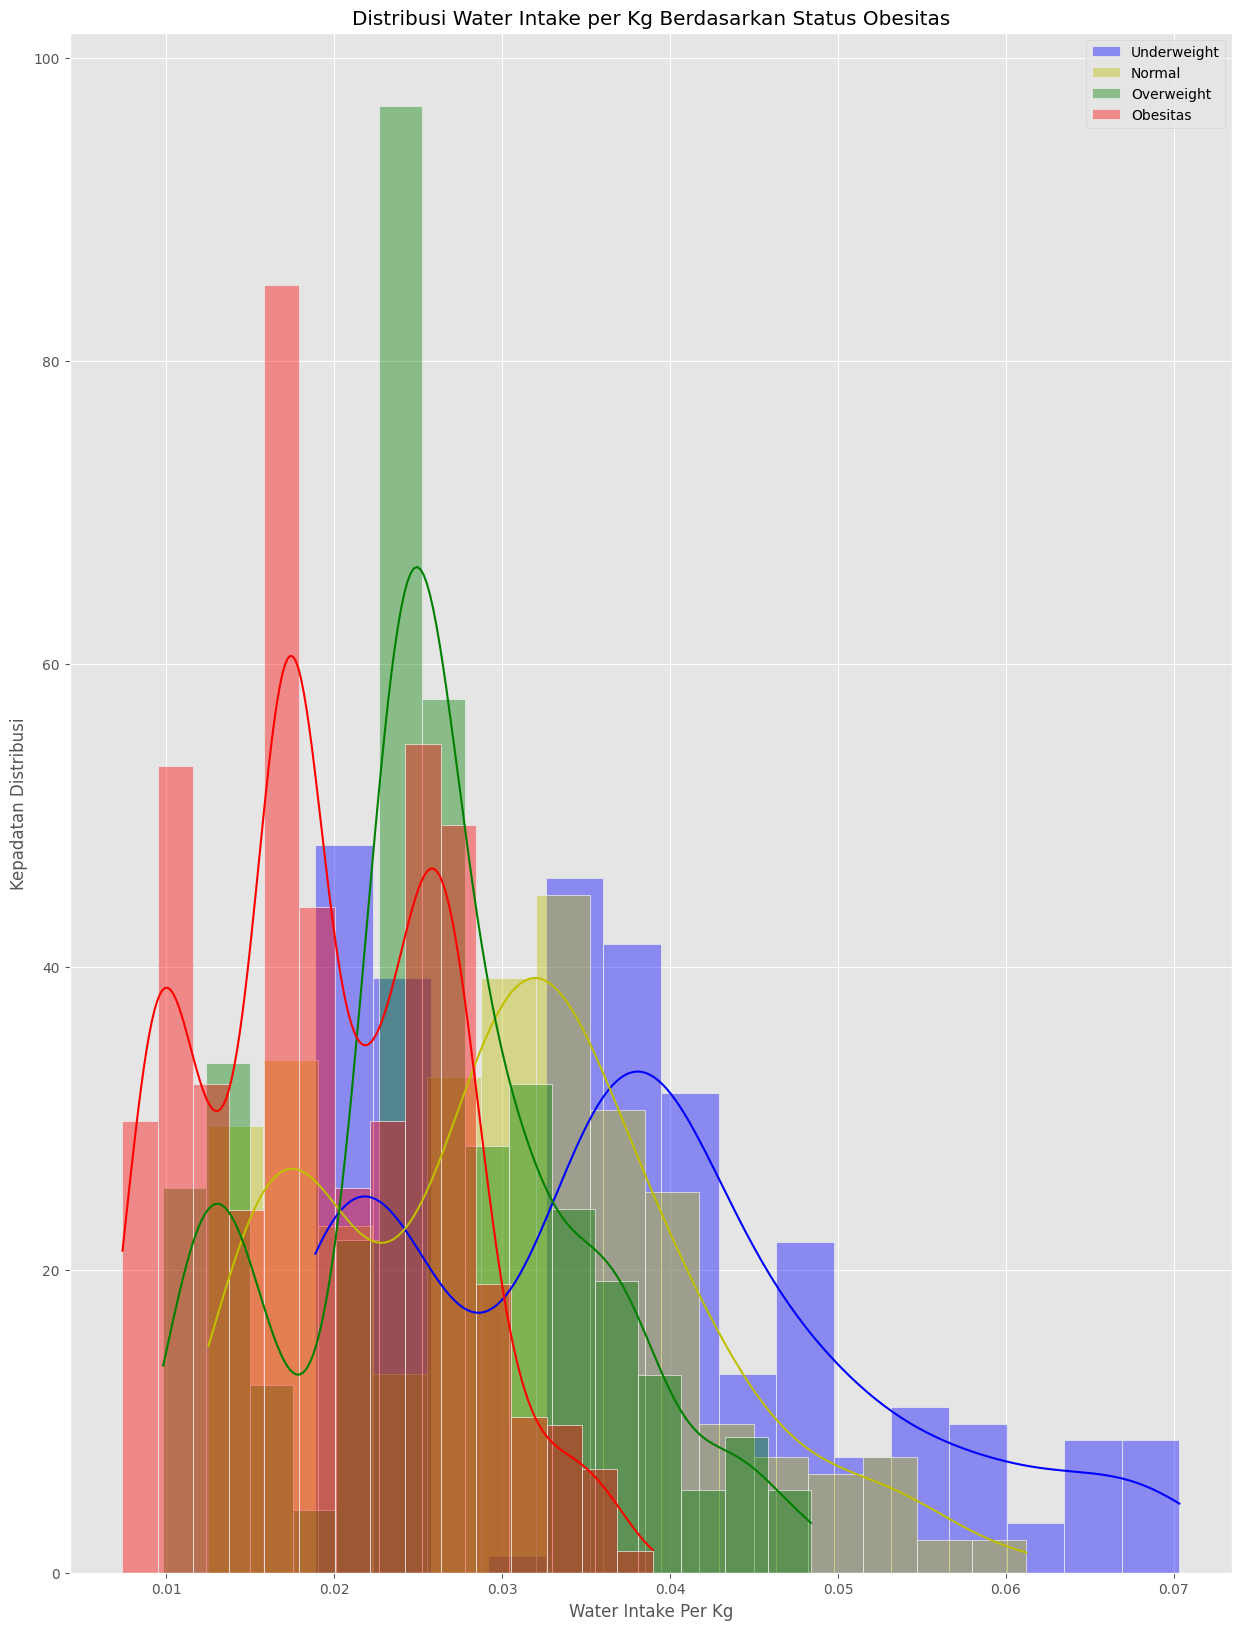

In [59]:


# Ganti distplot jadi histplot, tambah kde=True buat munculin garis kurvanya
# Bins diset ke 15 (jumlah keranjangnya), bukan pakai list rentang yang kebesaran
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Underweight'], bins=15, color="b", label="Underweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Normal'], bins=15, color="y", label="Normal", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Overweight'], bins=15, color="g", label="Overweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Obesity'], bins=15, color="r", label="Obesitas", kde=True, stat="density", alpha=0.4)

plt.title('Distribusi Water Intake per Kg Berdasarkan Status Obesitas')
plt.xlabel('Water Intake Per Kg')
plt.ylabel('Kepadatan Distribusi')
plt.legend()
plt.show()

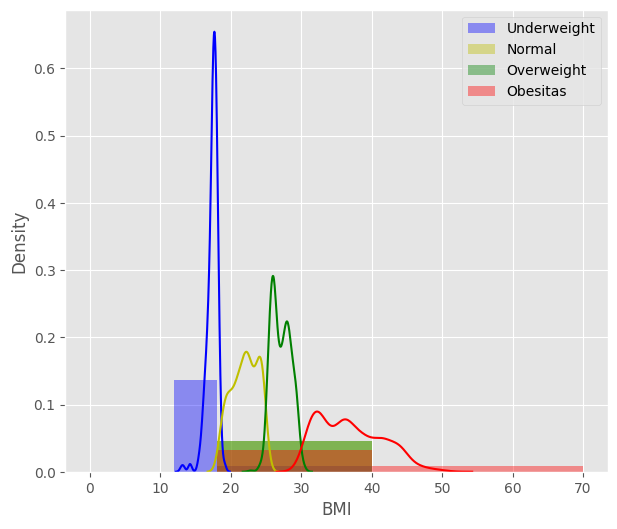

In [60]:
# Hubungan BMI dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.BMI[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.BMI[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.BMI[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.BMI[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



In [61]:
# Tambahin 'count' buat ngitung jumlah orang di tiap kelas
cek_rentang_bmi = df.groupby('Weight_Status')['BMI'].agg(['count', 'min', 'mean', 'max']).reset_index()

# Urutin dari rata-rata BMI terkecil ke terbesar biar enak dibaca
cek_rentang_bmi = cek_rentang_bmi.sort_values(by='mean')

# Ganti nama kolom biar lebih rapi pas ditampilin di laporan
cek_rentang_bmi.rename(columns={'count': 'Jumlah_Data', 'min': 'BMI_Min', 'mean': 'BMI_Rata2', 'max': 'BMI_Max'}, inplace=True)

print(cek_rentang_bmi)

  Weight_Status  Jumlah_Data  BMI_Min  BMI_Rata2  BMI_Max
3   Underweight          267   12.999     17.391   19.082
0        Normal          282   18.491     22.008   24.913
2    Overweight          566   22.827     27.114   30.363
1       Obesity          972   29.912     36.960   50.812


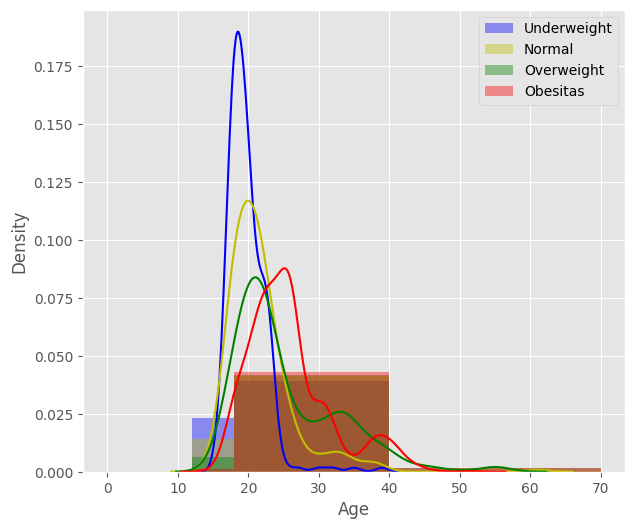

In [62]:
# Hubungan Age dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.Age[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.Age[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.Age[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.Age[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



*insight*
- Obesity dan Overweight cenderung dialami oleh usia diatas 25 tahun

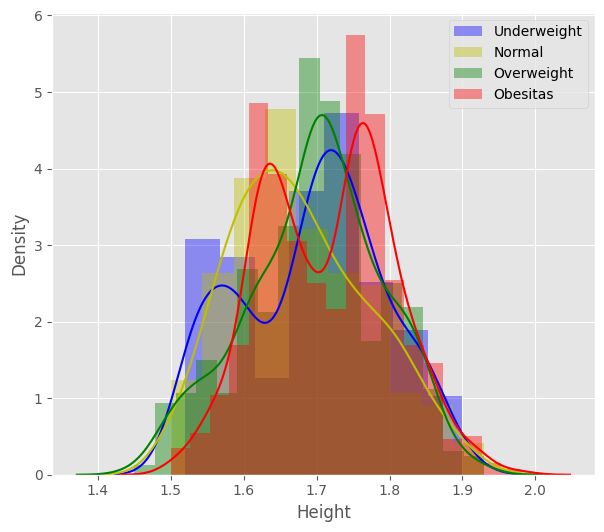

In [63]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Height[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Height[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Height[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Height[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()


*Insight*
- Tinggi badan antar kategori Weight_status memiliki distribusi yang cukup mirip.
- Tidak terdapat perbedaan signifikan tinggi badan pada tiap kategori obesitas.

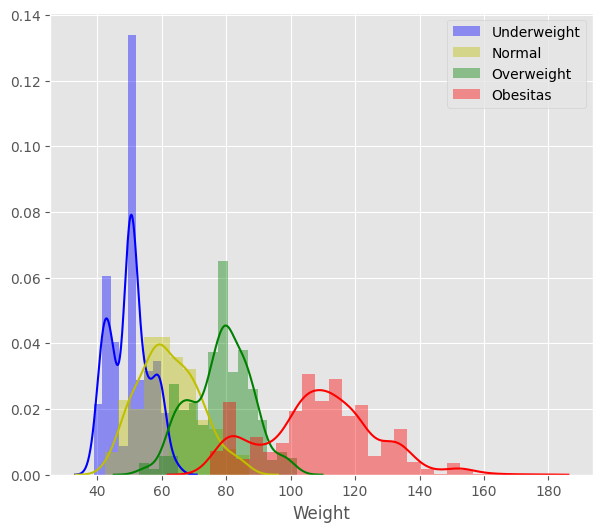

In [64]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Weight[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Weight[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Weight[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Weight[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.ylabel('')
plt.legend()



*Insight*
- Kelompok obesitas memiliki berat badan paling tinggi dibanding kategori lain.

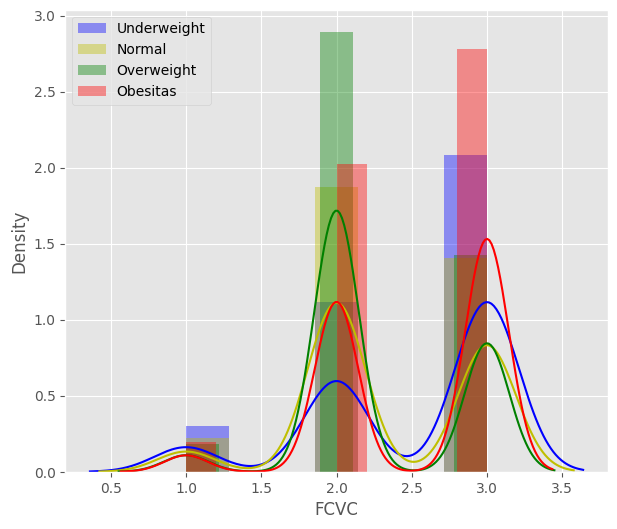

In [65]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FCVC[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FCVC[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*insight*
- Individu normal dan underweight cenderung memiliki konsumsi sayur lebih tinggi.
- Kelompok obesitas masih muncul pada tingkat konsumsi sayur rendah hingga sedang.

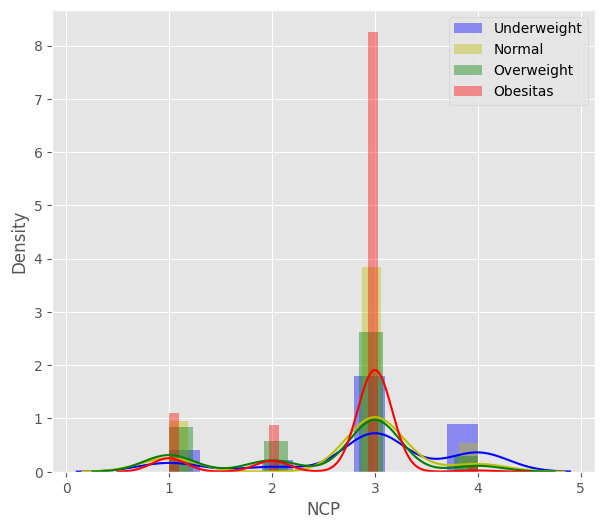

In [66]:
plt.figure(figsize=(7, 6))
sns.distplot(df.NCP[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.NCP[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.NCP[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.NCP[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Mayoritas responden mengonsumsi sekitar 3 kali makan utama per hari.

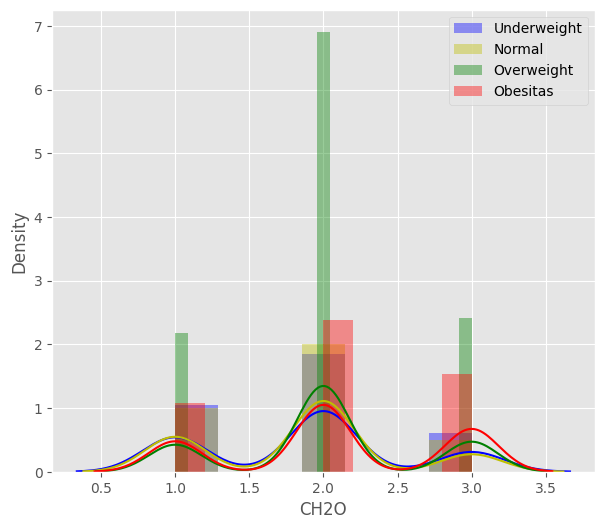

In [67]:
plt.figure(figsize=(7, 6))
sns.distplot(df.CH2O[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Normal'], color="y", label="Normal" )
sns.distplot(df.CH2O[df.Weight_Status == 'Overweight'], color="g", label="Overweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Obesity'], color="r", label="Obesitas" )
plt.legend()



*Insight*
- Sebagian besar responden berada pada tingkat konsumsi air sedang.
- Tidak terlihat perbedaan yang terlalu ekstrem antar kategori BMI.

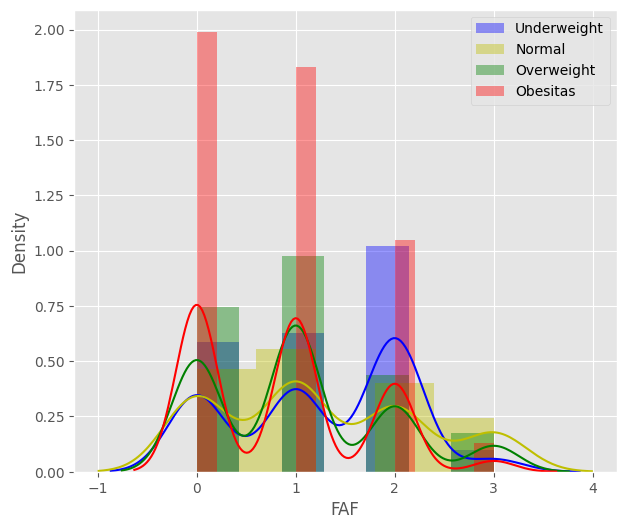

In [68]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FAF[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.FAF[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FAF[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FAF[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- FAF (Aktivitas Fisik) Untuk status weight nya normal dan underweight frekuensi aktivitas fisik nya lebih banyak dibndingkan status weight yang lain.

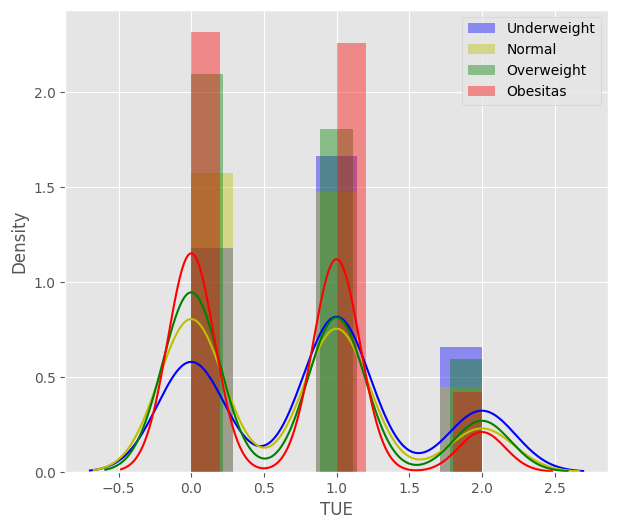

In [69]:
plt.figure(figsize=(7, 6))
sns.distplot(df.TUE[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.TUE[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.TUE[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.TUE[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Kelompok obesitas cenderung memiliki penggunaan teknologi lebih tinggi dibanding kategori lain.
- Individu underweight lebih banyak berada pada durasi penggunaan teknologi rendah.

*Cek Outlier di Fitur numerik*

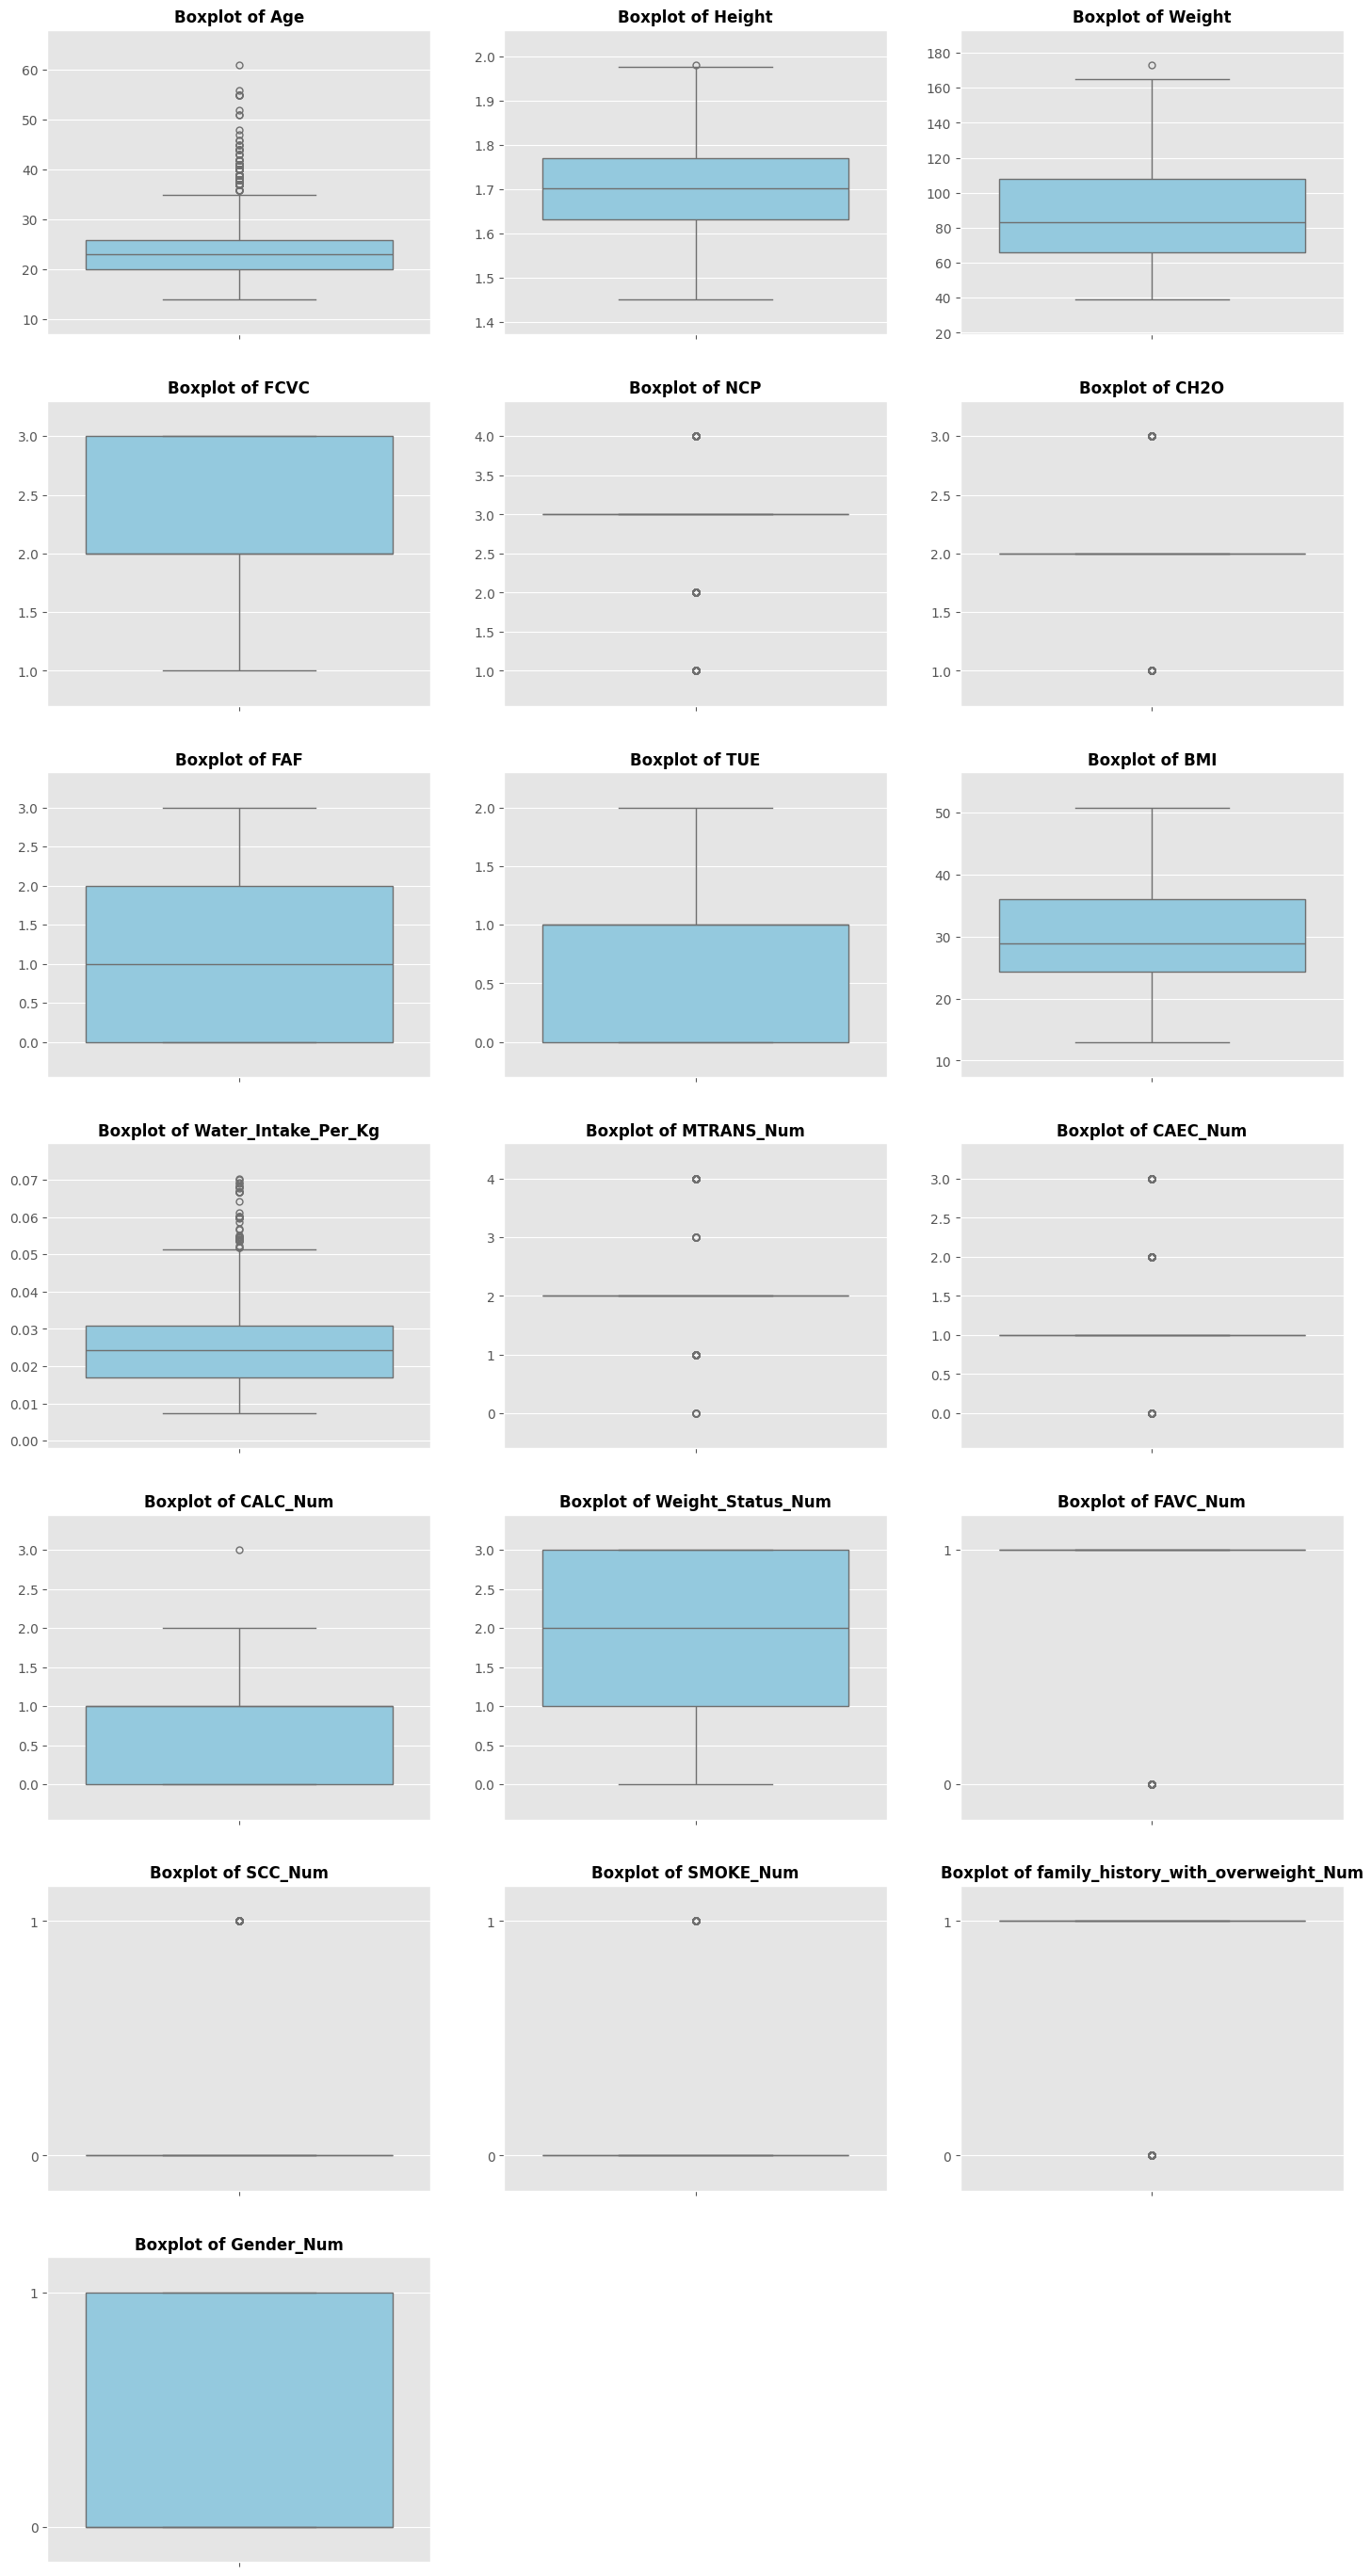

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
n_cols = len(numeric_cols)

cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 2. Atur ukuran kanvas dinamis
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    ax = plt.subplot(rows, cols_per_row, i)

    # Plot boxplot
    sns.boxplot(y=df[col], color='skyblue', fliersize=5, ax=ax)

    # SET RENTANG Y DINAMIS:
    # Kita ambil nilai min dan max, lalu kasih margin 10% biar nggak nempel garis
    y_min = df[col].min()
    y_max = df[col].max()
    margin = (y_max - y_min) * 0.15 if y_max != y_min else 0.5

    # Set limit Y supaya yang cuma 0-1 nggak kelihatan kayak garis doang
    ax.set_ylim(y_min - margin, y_max + margin)

    # Kalau datanya cuma 0 dan 1 (Binary), kita paksa tick-nya cuma di 0 dan 1
    if y_min == 0 and y_max == 1:
        ax.set_yticks([0, 1])

    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout(pad=3.0)

plt.show()

*Hubungan Fitur Kategorikal dengan Target*

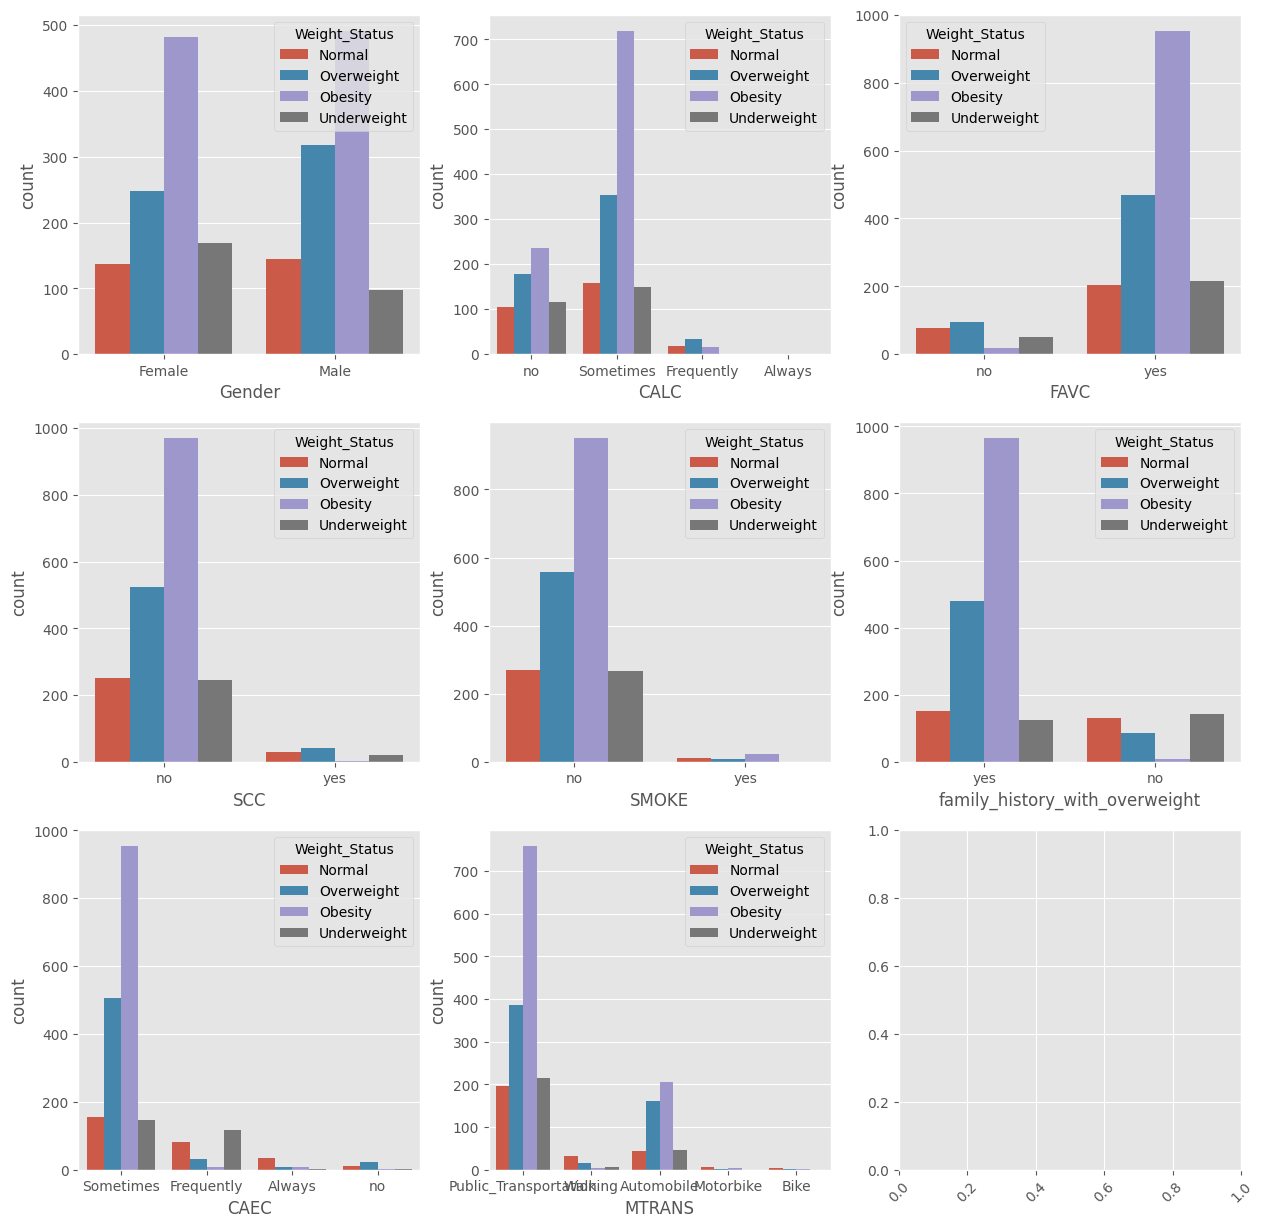

In [71]:
cat_var = ["Gender", "CALC", "FAVC", "SCC", "SMOKE", "family_history_with_overweight", "CAEC", "MTRANS"]

fig, axes = plt.subplots(3,3, figsize=(15,15))
plt.xticks(rotation=45)

for cat, ax in zip(cat_var, axes.flatten()):
    sns.countplot(x=cat, data=df, hue="Weight_Status", ax=ax)

*Insight*
- Konsumsi makanan tinggi kalori (FAVC) terlihat lebih sering muncul pada kategori obesitas.
- Frekuensi konsumsi sayur (FCVC) yang rendah cenderung lebih banyak pada kelompok obesitas.
- Kebiasaan merokok (SMOKE) tidak menunjukkan pengaruh yang terlalu besar terhadap obesitas pada dataset ini.
- Penggunaan transportasi (MTRANS) memperlihatkan bahwa individu yang lebih pasif cenderung berada di kategori overweight/obesitas.

*Analisis Korelasi*

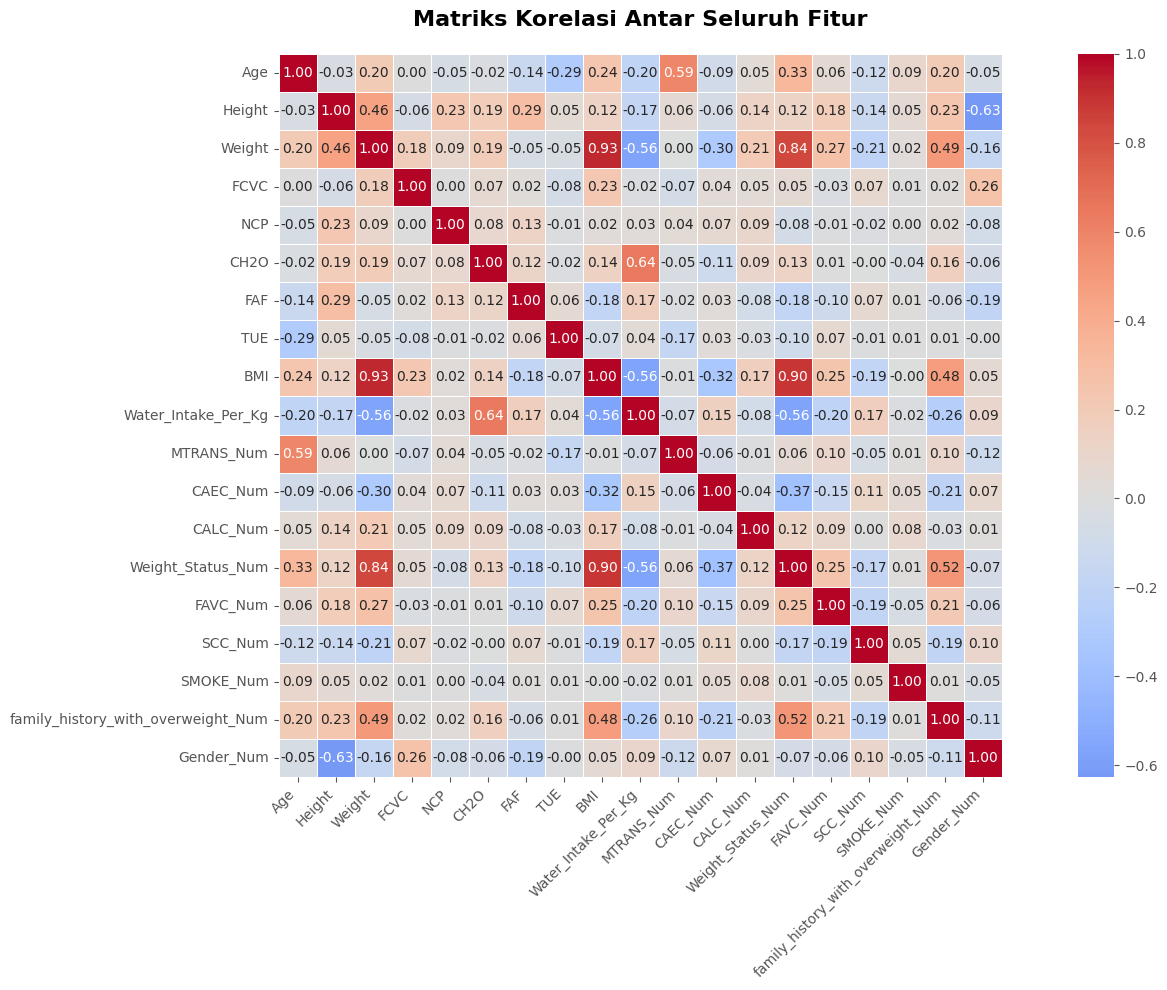

In [72]:
# --- 4. VISUALISASI KORELASI ANTAR FITUR ---
# Hitung matriks korelasi hanya untuk kolom numerik
fitur_angka = df.select_dtypes(include=['number']).columns
corr_matrix = df[fitur_angka].corr()

plt.figure(figsize=(16, 10))

# Membuat heatmap kotak penuh
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            square=True) # Menjaga bentuk sel tetap kotak

plt.title('Matriks Korelasi Antar Seluruh Fitur', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

*Insight*
- Weight memiliki korelasi paling tinggi terhadap obesitas, sehingga berat badan menjadi faktor utama dalam klasifikasi obesitas.
- Height dan Weight memiliki korelasi positif sedang, artinya semakin tinggi seseorang biasanya berat badannya juga meningkat.
- Age memiliki korelasi negatif terhadap TUE (penggunaan teknologi), menunjukkan usia lebih muda cenderung lebih sering menggunakan perangkat teknologi.

*Cek Outlier di Fitur numerik*

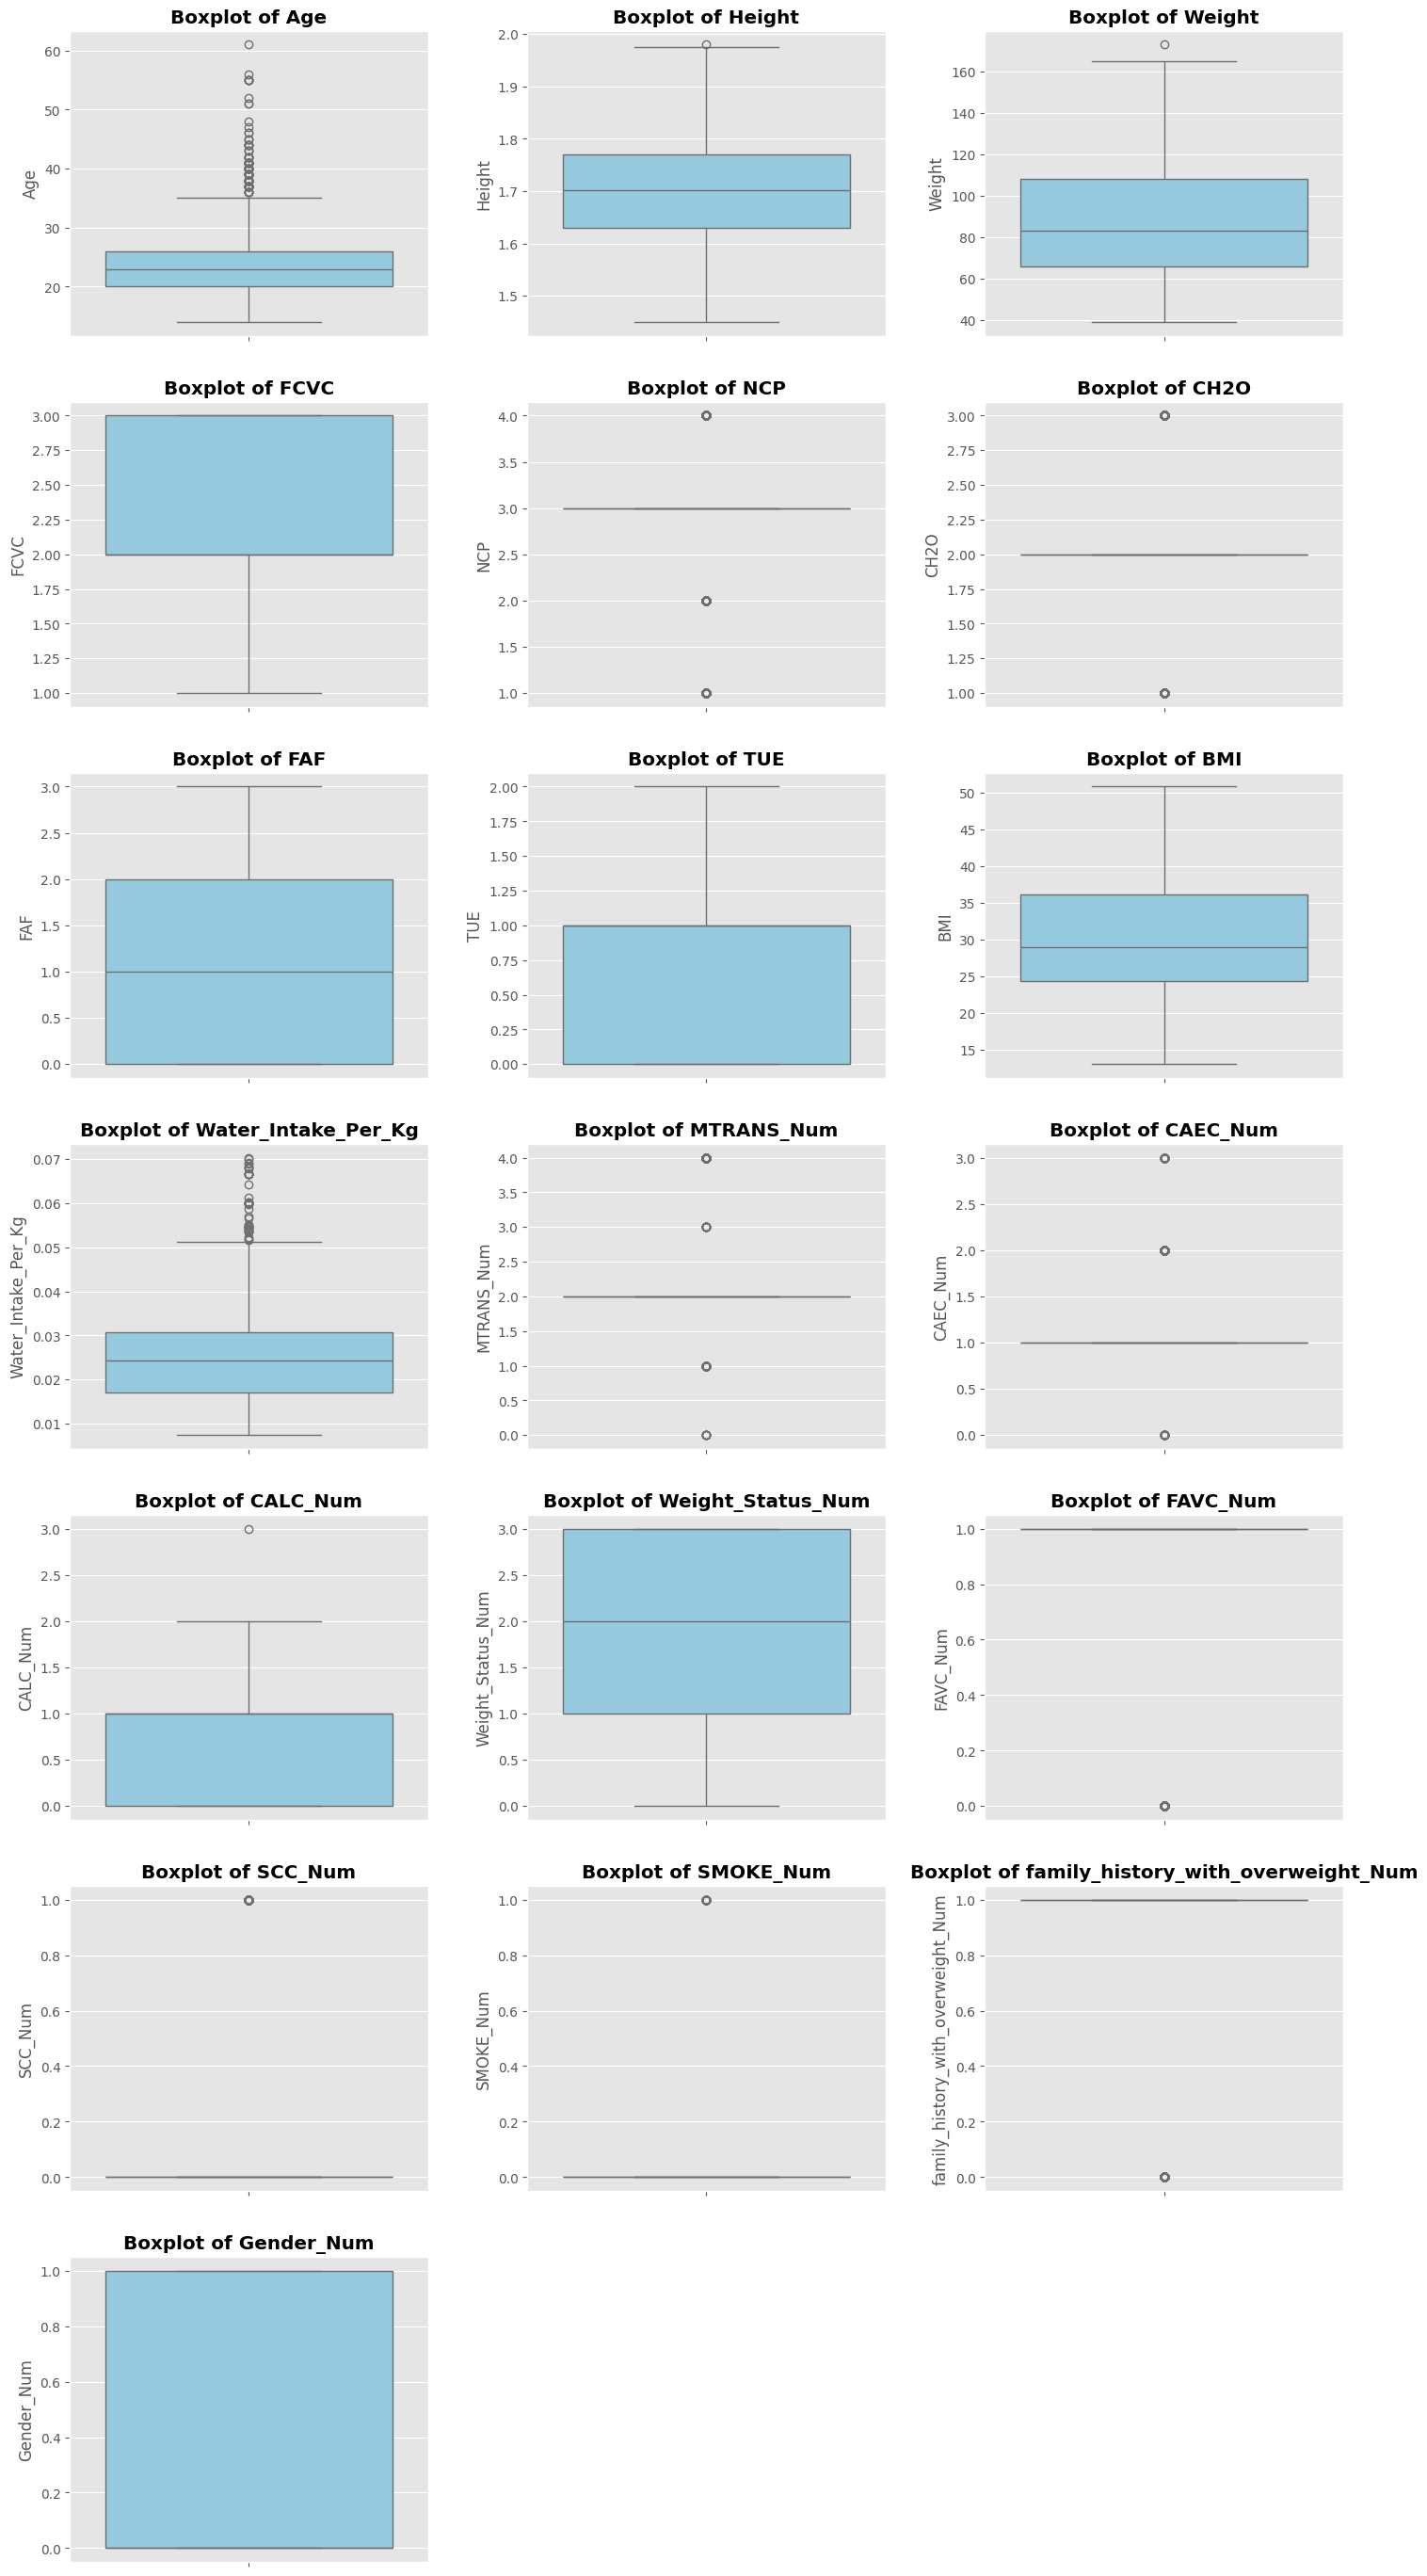

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik (termasuk hasil encoding int32/int64)
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)

# 2. Tentukan grid (3 kolom per baris)
cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 3. Atur ukuran kanvas secara DINAMIS (Tinggi = jumlah baris x 4 unit)
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontweight='bold')
    plt.tight_layout(pad=3.0) # Memberikan jarak antar subplot agar judul tidak tabrakan

plt.show()

# Data Visualization & Explanatory


Pertanyaan 1 : Bagaimana Distribusi Data Kolom Weight_Status Sebagai Target ?

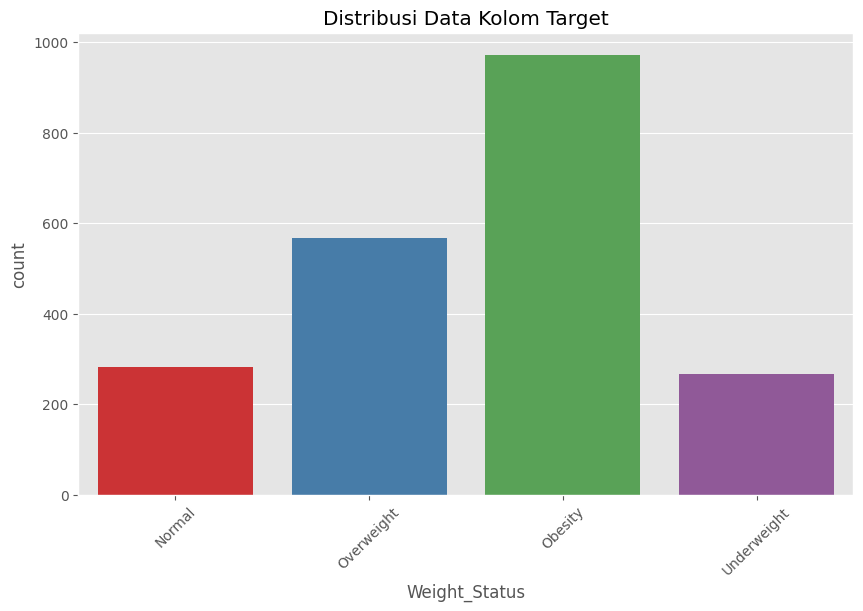

In [74]:
# Distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(x='Weight_Status', data=df, palette='Set1')
plt.title('Distribusi Data Kolom Target')
plt.xticks(rotation=45)
plt.show()

Pertanyaan 2: Hubungan Antara Usia dengan Weight_Status

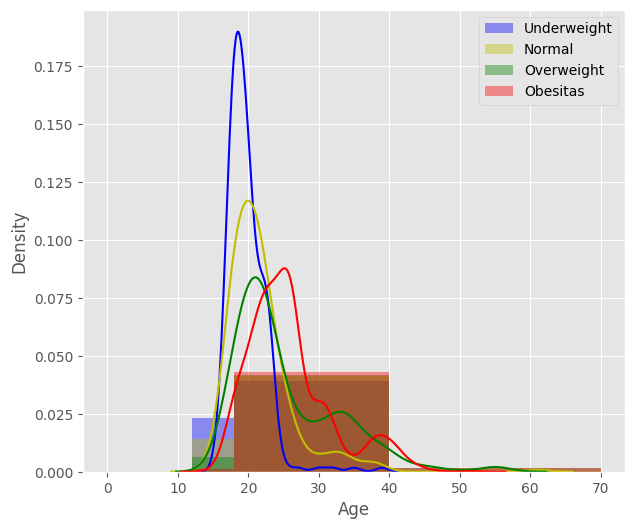

In [75]:
# Hubungan Age dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.Age[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.Age[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.Age[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.Age[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



Dari visualisasi tersebut dapat dilihat bahwa obesitas dapat dialami oleh usia di atas 25 tahun

Pertanyaan 3: Apa Fitur yang Paling Signifikan dengan Target ?

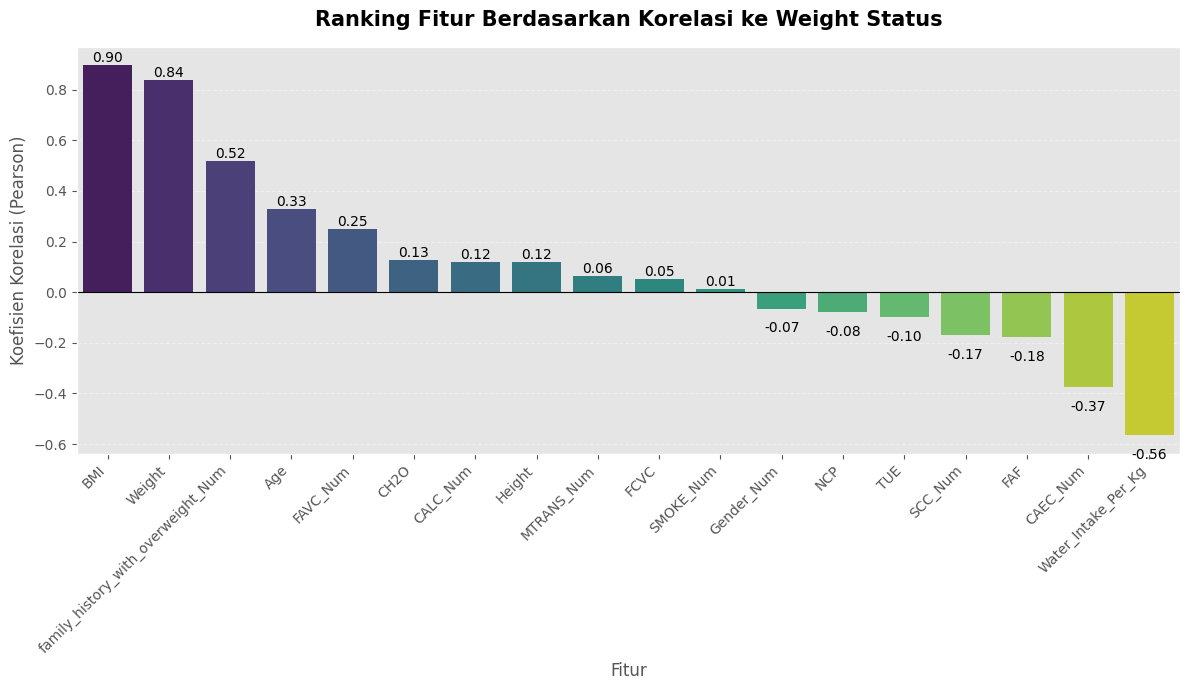

In [76]:
# --- 5. BAR PLOT KORELASI TERHADAP TARGET ---
# Ambil korelasi spesifik ke target, hapus baris target itu sendiri, dan urutkan
target_corr = corr_matrix['Weight_Status_Num'].drop('Weight_Status_Num').sort_values(ascending=False)

plt.figure(figsize=(12, 7))

# Plotting
sns.barplot(x=target_corr.index,
            y=target_corr.values,
            hue=target_corr.index,
            palette='viridis',
            legend=False)

# Tambahan garis bantu di y=0
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Ranking Fitur Berdasarkan Korelasi ke Weight Status', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Fitur', fontsize=12)
plt.ylabel('Koefisien Korelasi (Pearson)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Tambahkan label nilai di atas bar (opsional tapi sangat membantu)
for i, v in enumerate(target_corr.values):
    plt.text(i, v if v > 0 else v - 0.05, f'{v:.2f}', ha='center', va='bottom' if v > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()

*Insight*

3 Fitur paling Signifikan dengan Target Ialah Weight, family_history_with_overweight dan Age


## Splitting Data

In [77]:
from sklearn.model_selection import train_test_split

# Split data utama jadi train dan test dengan proporsi 80:20
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Weight_Status'])

# Drop kolom target di df_test biar murni jadi data buat ujian
df_test.drop(columns=['Weight_Status'], inplace=True)

# Cek hasil split
print(f"Dimensi df_train: {df_train.shape}")
print(f"Dimensi df_test : {df_test.shape}")
print("=" * 50)

# Cek hasil splitting
print("Kolom di df_train:")
print(df_train.columns.tolist())
print("=" * 50)
print("Kolom di df_test:")
print(df_test.columns.tolist())

Dimensi df_train: (1669, 28)
Dimensi df_test : (418, 27)
Kolom di df_train:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'Weight_Status', 'BMI', 'Water_Intake_Per_Kg', 'MTRANS_Num', 'CAEC_Num', 'CALC_Num', 'Weight_Status_Num', 'FAVC_Num', 'SCC_Num', 'SMOKE_Num', 'family_history_with_overweight_Num', 'Gender_Num']
Kolom di df_test:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'BMI', 'Water_Intake_Per_Kg', 'MTRANS_Num', 'CAEC_Num', 'CALC_Num', 'Weight_Status_Num', 'FAVC_Num', 'SCC_Num', 'SMOKE_Num', 'family_history_with_overweight_Num', 'Gender_Num']


## Data Transformation

### Feature Selection

In [78]:
# 1. Tentukan list fitur yang akan dipertahankan (tanpa target untuk test set)
features_to_keep = [
    'Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF',
    'family_history_with_overweight_Num', 'CAEC_Num',
    'FAVC_Num', 'SCC_Num'
]

# 2. Filter df_train (Pertahankan Fitur + Target)
# Kita butuh 'Weight_Status_Num' di train untuk proses belajar model
df_train = df_train[features_to_keep + ['Weight_Status_Num']].copy()

# 3. Filter df_test (Hanya Fitur)
# Kita hanya menyisakan fitur agar formatnya sama dengan input user nanti
df_test = df_test[features_to_keep].copy()

# --- VERIFIKASI AKHIR ---
print("✅ Seleksi Fitur Berhasil!")
print(f"Dimensi df_train: {df_train.shape} (8 Fitur + 1 Target)")
print(f"Dimensi df_test : {df_test.shape} (8 Fitur)")
print("-" * 30)
print("Fitur yang digunakan untuk pelatihan & input user:")
print(df_test.columns.tolist())

✅ Seleksi Fitur Berhasil!
Dimensi df_train: (1669, 9) (8 Fitur + 1 Target)
Dimensi df_test : (418, 8) (8 Fitur)
------------------------------
Fitur yang digunakan untuk pelatihan & input user:
['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num']


In [79]:
df_train

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
1401,39,33.014,0.013,0,1,1.0,1,0,3.0
2087,26,41.910,0.027,0,1,1.0,1,0,3.0
1324,22,31.988,0.024,0,1,1.0,1,0,3.0
664,22,17.906,0.039,0,1,2.0,1,0,0.0
835,29,25.912,0.029,2,1,1.0,1,0,2.0
...,...,...,...,...,...,...,...,...,...
2056,26,41.695,0.027,0,1,1.0,1,0,3.0
771,23,25.705,0.026,0,1,2.0,1,0,2.0
201,41,33.733,0.013,0,1,3.0,1,0,3.0
1765,31,37.498,0.016,1,1,1.0,1,0,3.0


In [80]:
df_test

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num
598,18,17.554,0.039,0,1,1.0,1,0
780,20,26.058,0.024,1,1,1.0,1,0
1772,25,36.839,0.017,1,1,1.0,1,0
2010,26,40.144,0.010,0,1,1.0,1,0
311,17,20.957,0.032,3,0,3.0,1,0
...,...,...,...,...,...,...,...,...
123,24,24.314,0.030,1,1,1.0,1,0
1263,38,30.830,0.025,2,1,1.0,1,0
384,18,23.437,0.017,0,1,1.0,1,1
874,16,25.970,0.029,1,1,1.0,1,0


### Normalization

In [81]:
from sklearn.preprocessing import QuantileTransformer
import joblib
import pandas as pd

scaler = QuantileTransformer(output_distribution='normal', random_state=42)

# Fitur yang diproses (Kontinu)
columns_to_scale = ['Age', 'BMI', 'Water_Intake_Per_Kg']

# Fitur yang dibiarkan murni (Diskrit/Kategori)
unscaled_features = [
    'FAF', 'family_history_with_overweight_Num',
    'FAVC_Num', 'SCC_Num', 'CAEC_Num'
]

# Eksekusi Scaling
df_train_scaled = df_train.copy()
df_train_scaled[columns_to_scale] = scaler.fit_transform(df_train[columns_to_scale])

df_test_scaled = df_test.copy()
df_test_scaled[columns_to_scale] = scaler.transform(df_test[columns_to_scale])

# Cek nilai unik semua fitur yang TIDAK di-scale
print("--- NILAI UNIK FITUR NON-SCALED ---")
for col in unscaled_features:
    unique_vals = sorted(df_train_scaled[col].unique())
    print(f"{col:35} : {unique_vals}")

# Liat tabel buat bandingin angka scaled vs non-scaled
print("\n--- SAMPEL DATA HASIL AKHIR ---")
display_cols = columns_to_scale + unscaled_features
print(df_train_scaled[display_cols].head(10))

# Simpan objek scaler
joblib.dump(scaler, 'scaler_obesitas.pkl')
print("\n✅ Scaler berhasil disimpan sebagai 'scaler_obesitas.pkl'")

--- NILAI UNIK FITUR NON-SCALED ---
FAF                                 : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
family_history_with_overweight_Num  : [np.int64(0), np.int64(1)]
FAVC_Num                            : [np.int64(0), np.int64(1)]
SCC_Num                             : [np.int64(0), np.int64(1)]
CAEC_Num                            : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

--- SAMPEL DATA HASIL AKHIR ---
        Age    BMI  Water_Intake_Per_Kg  FAF  \
1401  1.733  0.415               -1.159    0   
2087  0.572  1.391                0.393    0   
1324 -0.156  0.257                0.013    0   
664  -0.156 -1.281                1.300    0   
835   0.864 -0.452                0.557    2   
40   -0.388 -0.289                0.335    1   
1425  0.069  0.158                0.754    3   
1366 -1.328  0.173               -1.302    1   
1754  0.763  0.758                0.183    1   
851  -0.388 -0.582                0.225    3   

      fam

In [82]:
df_train_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
count,1669.000,1.669e+03,1.669e+03,1669.000,1669.000,1669.000,1669.000,1669.000,1669.000
mean,0.004,-8.063e-05,-7.316e-05,1.029,0.828,1.140,0.886,0.044,2.074
std,1.001,1.012e+00,1.012e+00,0.904,0.377,0.454,0.318,0.206,1.053
min,-5.199,-5.199e+00,-5.199e+00,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.641,-6.746e-01,-6.737e-01,0.000,1.000,1.000,1.000,0.000,1.000
50%,0.069,5.532e-04,-5.133e-04,1.000,1.000,1.000,1.000,0.000,2.000
75%,0.572,6.740e-01,6.738e-01,2.000,1.000,1.000,1.000,0.000,3.000
max,5.199,5.199e+00,5.199e+00,3.000,1.000,3.000,1.000,1.000,3.000


In [83]:
df_test_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num
count,418.000,418.000,418.000,418.000,418.000,418.000,418.000,418.000
mean,-0.011,-0.005,0.048,0.931,0.813,1.172,0.876,0.053
std,0.991,0.973,1.040,0.875,0.390,0.479,0.330,0.224
min,-2.575,-2.242,-3.051,0.000,0.000,0.000,0.000,0.000
25%,-0.641,-0.677,-0.607,0.000,1.000,1.000,1.000,0.000
50%,0.069,-0.052,0.074,1.000,1.000,1.000,1.000,0.000
75%,0.572,0.647,0.753,2.000,1.000,1.000,1.000,0.000
max,2.878,2.738,5.199,3.000,1.000,3.000,1.000,1.000


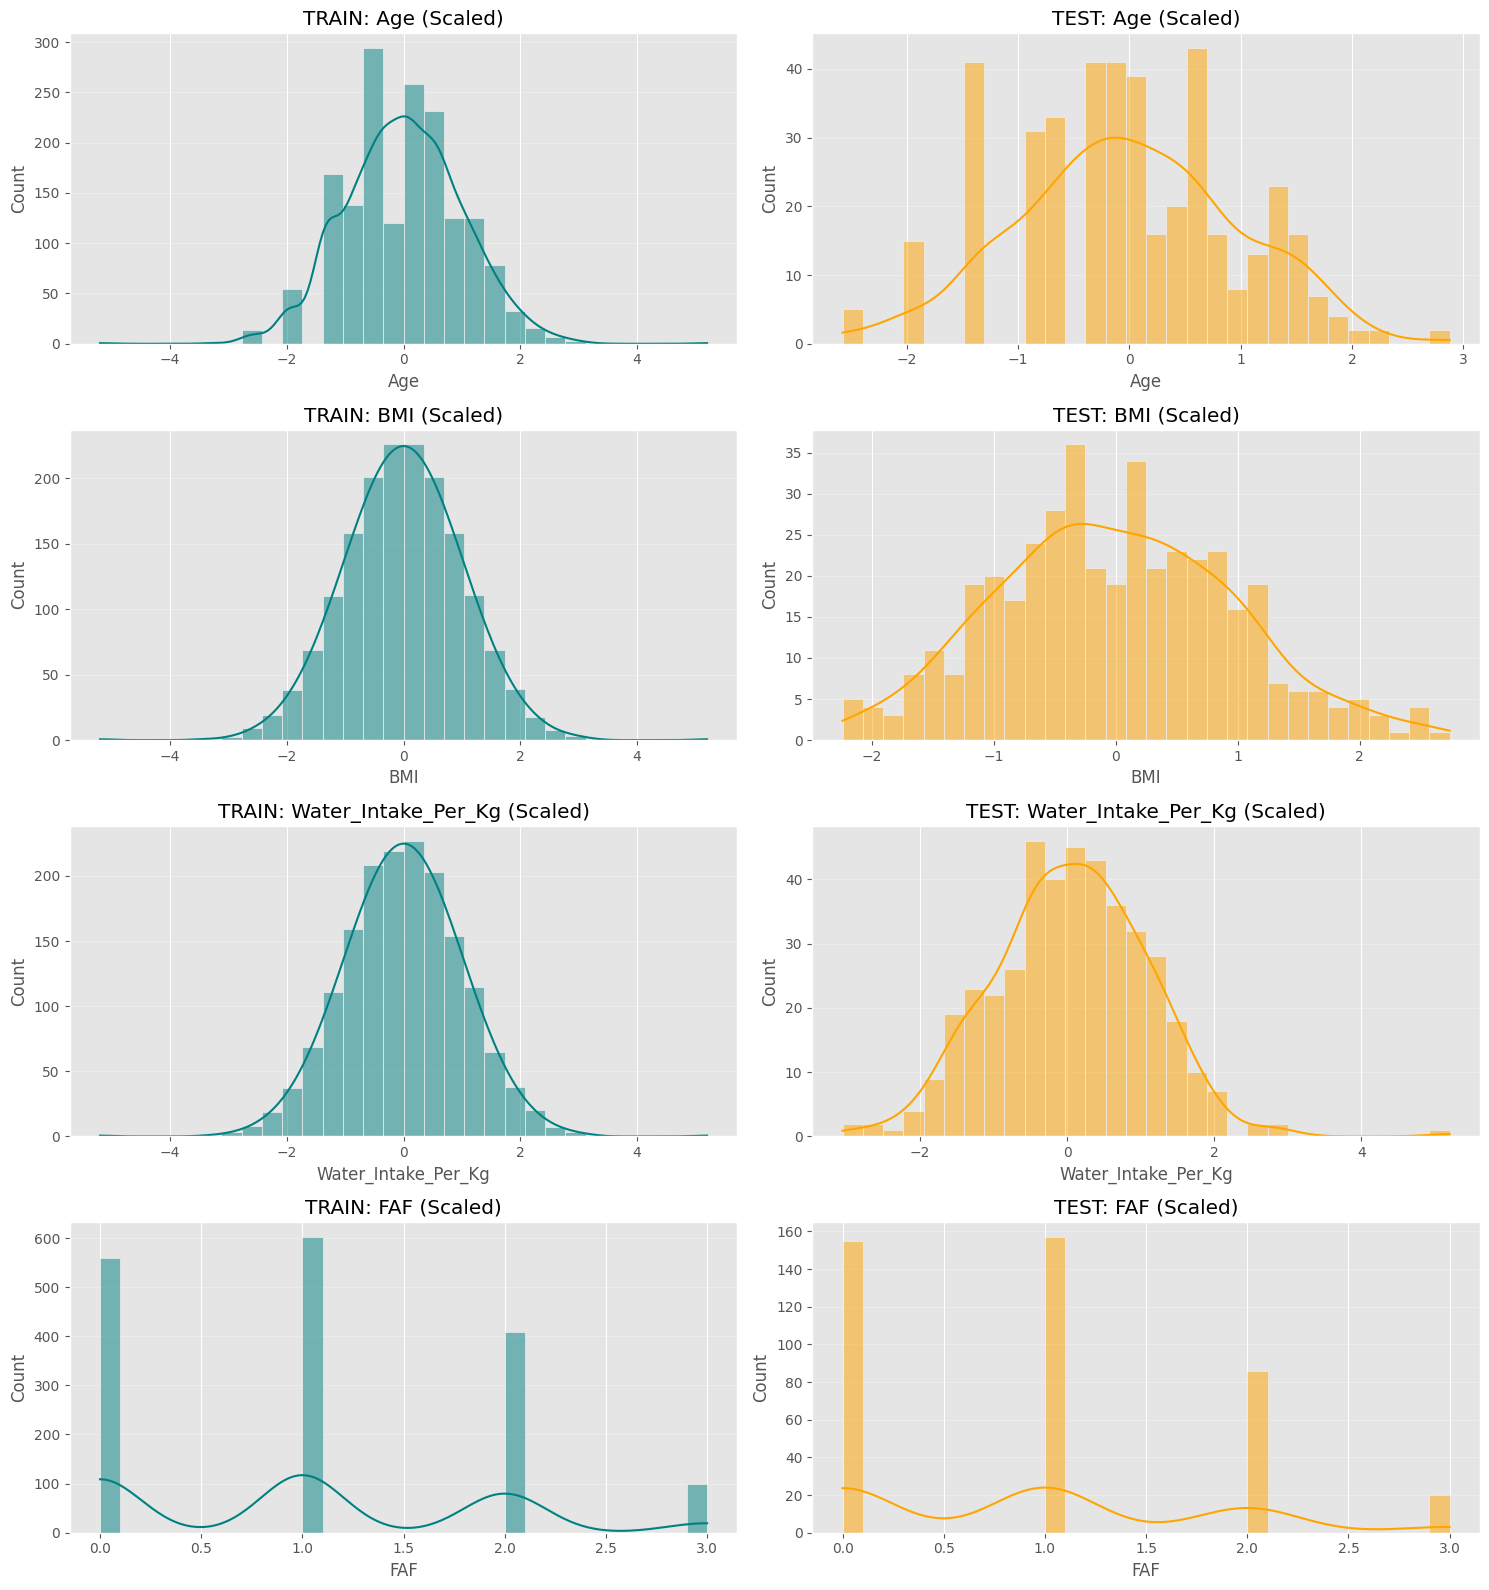

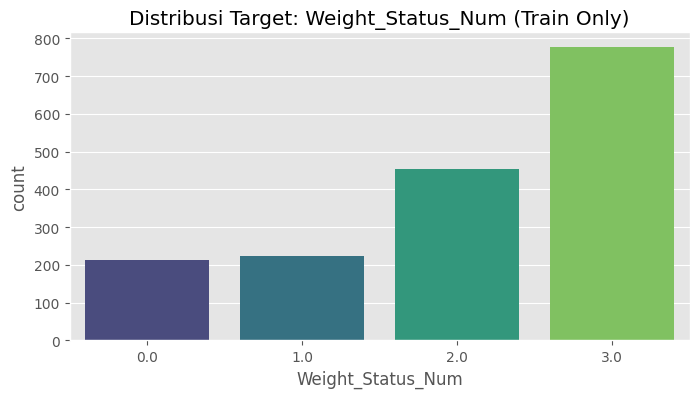

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Tentukan list fitur yang di-scale + target (khusus di train)
features_to_plot = ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF']
target_col = 'Weight_Status_Num'

# 2. Pengaturan Grid (Baris disesuaikan dengan jumlah fitur)
n_cols = 2 # Kolom kiri untuk Train, Kolom kanan untuk Test
n_rows = len(features_to_plot)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features_to_plot):
    # --- PLOT DATA TRAIN (KIRI) ---
    plt.subplot(n_rows, n_cols, 2*i + 1)
    sns.histplot(df_train_scaled[col], kde=True, color='teal', bins=30)
    plt.title(f'TRAIN: {col} (Scaled)')
    plt.grid(axis='y', alpha=0.3)

    # --- PLOT DATA TEST (KANAN) ---
    plt.subplot(n_rows, n_cols, 2*i + 2)
    sns.histplot(df_test_scaled[col], kde=True, color='orange', bins=30)
    plt.title(f'TEST: {col} (Scaled)')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Khusus Visualisasi Target (Hanya ada di Train)
plt.figure(figsize=(8, 4))
sns.countplot(x=df_train_scaled[target_col], palette='viridis')
plt.title(f'Distribusi Target: {target_col} (Train Only)')
plt.show()

*Save data hasil scaling dalam format csv*

In [85]:
# Simpan Data Train yang sudah di-scale
df_train_scaled.to_csv('df_train_scaled.csv', index=False)

# Simpan Data Test yang sudah di-scale
df_test_scaled.to_csv('df_test_scaled.csv', index=False)

print("✅ File CSV berhasil disimpan!")

✅ File CSV berhasil disimpan!


## Modeling

## Modeling

### Persiapan Data (X dan y)

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data yang sudah di-scale
df_train_scaled = pd.read_csv('df_train_scaled.csv')
df_test_scaled  = pd.read_csv('df_test_scaled.csv')

# Pisahkan fitur dan target dari data training
X_train = df_train_scaled.drop(columns=['Weight_Status_Num'])
y_train = df_train_scaled['Weight_Status_Num'].astype(int)

print("Shape X_train :", X_train.shape)
print("Shape y_train :", y_train.shape)
print("Shape X_test  :", df_test_scaled.shape)
print()
print("Distribusi Target (y_train):")
print(y_train.value_counts().sort_index()
      .rename({0:'Underweight', 1:'Normal', 2:'Overweight', 3:'Obesity'}))


Shape X_train : (1669, 8)
Shape y_train : (1669,)
Shape X_test  : (418, 8)

Distribusi Target (y_train):
Weight_Status_Num
Underweight    214
Normal         225
Overweight     453
Obesity        777
Name: count, dtype: int64


### Import Library Model

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import joblib

print("✅ Semua library model berhasil di-import!")


✅ Semua library model berhasil di-import!


### Perbandingan Multi-Model dengan Cross-Validation (5-Fold)

In [88]:
# Definisi semua model yang akan dibandingkan
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=7),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', C=1, probability=True, random_state=42),
    'Naive Bayes'         : GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'f1_weighted']

results = {}
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Macro':>10} {'F1-Weighted':>12} {'Std Acc':>9}")
print("-" * 70)

for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    acc    = cv_res['test_accuracy'].mean()
    std    = cv_res['test_accuracy'].std()
    f1m    = cv_res['test_f1_macro'].mean()
    f1w    = cv_res['test_f1_weighted'].mean()
    results[name] = {'accuracy': acc, 'std': std, 'f1_macro': f1m, 'f1_weighted': f1w}
    print(f"{name:<25} {acc:>10.4f} {f1m:>10.4f} {f1w:>12.4f} {std:>9.4f}")

df_results = pd.DataFrame(results).T.sort_values('f1_weighted', ascending=False)
print()
print("🏆 Model Terbaik Berdasarkan F1-Weighted:", df_results.index[0])


Model                       Accuracy   F1-Macro  F1-Weighted   Std Acc
----------------------------------------------------------------------
Logistic Regression           0.9515     0.9328       0.9509    0.0096
K-Nearest Neighbors           0.8724     0.8250       0.8688    0.0210
Decision Tree                 0.9886     0.9847       0.9886    0.0035
Random Forest                 0.9910     0.9861       0.9910    0.0042
Extra Trees                   0.9599     0.9480       0.9600    0.0132
Gradient Boosting             0.9880     0.9846       0.9881    0.0071
SVM (RBF)                     0.9533     0.9349       0.9531    0.0181
Naive Bayes                   0.7556     0.7488       0.7254    0.0333

🏆 Model Terbaik Berdasarkan F1-Weighted: Random Forest


### Visualisasi Perbandingan Performa Model

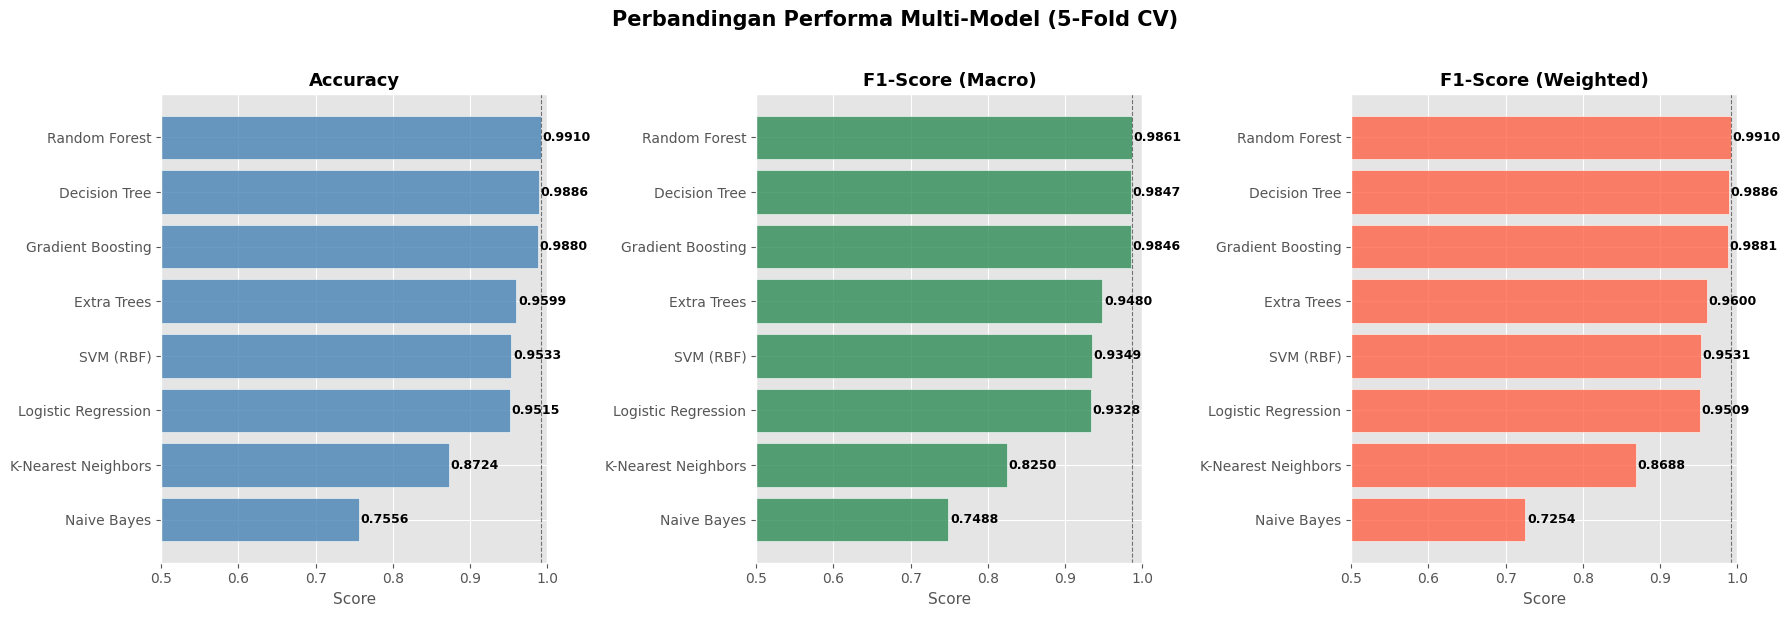

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['accuracy', 'f1_macro', 'f1_weighted']
titles  = ['Accuracy', 'F1-Score (Macro)', 'F1-Score (Weighted)']
colors  = ['steelblue', 'seagreen', 'tomato']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    df_plot = df_results[metric].sort_values(ascending=True)
    bars = ax.barh(df_plot.index, df_plot.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Score', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0.5, 1.0)
    ax.axvline(df_plot.max(), color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, df_plot.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Perbandingan Performa Multi-Model (5-Fold CV)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Ringkasan Hasil Cross-Validation

In [90]:
# Tampilkan tabel hasil CV yang rapi
display_df = df_results.copy()
display_df.columns = ['Accuracy (CV Mean)', 'Std Accuracy', 'F1-Macro', 'F1-Weighted']
display_df = display_df.round(4)
display_df.index.name = 'Model'

print("=" * 65)
print("       Tabel Perbandingan Performa Model (5-Fold CV)")
print("=" * 65)
print(display_df.to_string())
print()

best_model_name = df_results['f1_weighted'].idxmax()
best_score      = df_results.loc[best_model_name, 'f1_weighted']
print(f"🏆 Model Terpilih : {best_model_name}")
print(f"   F1-Weighted    : {best_score:.4f}")
print(f"   Accuracy (CV)  : {df_results.loc[best_model_name, 'accuracy']:.4f}")


       Tabel Perbandingan Performa Model (5-Fold CV)
                     Accuracy (CV Mean)  Std Accuracy  F1-Macro  F1-Weighted
Model                                                                       
Random Forest                     0.991         0.004     0.986        0.991
Decision Tree                     0.989         0.004     0.985        0.989
Gradient Boosting                 0.988         0.007     0.985        0.988
Extra Trees                       0.960         0.013     0.948        0.960
SVM (RBF)                         0.953         0.018     0.935        0.953
Logistic Regression               0.952         0.010     0.933        0.951
K-Nearest Neighbors               0.872         0.021     0.825        0.869
Naive Bayes                       0.756         0.033     0.749        0.725

🏆 Model Terpilih : Random Forest
   F1-Weighted    : 0.9910
   Accuracy (CV)  : 0.9910


## Model Evaluation

### Training Model Terbaik & Evaluasi Detail

In [91]:
from sklearn.model_selection import train_test_split

# Split sebagian df_train jadi validation set untuk evaluasi akhir
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Inisialisasi ulang model terbaik
best_model = models[best_model_name]
best_model.fit(X_tr, y_tr)

# Prediksi di validation set
y_pred_val = best_model.predict(X_val)

print(f"Model   : {best_model_name}")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1-Macro: {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print()

label_names = ['Underweight', 'Normal', 'Overweight', 'Obesity']
print("=" * 55)
print("Classification Report (Validation Set)")
print("=" * 55)
print(classification_report(y_val, y_pred_val, target_names=label_names))


Model   : Random Forest
Accuracy: 0.9910
F1-Macro: 0.9861

Classification Report (Validation Set)
              precision    recall  f1-score   support

 Underweight       1.00      0.98      0.99        43
      Normal       0.96      0.98      0.97        45
  Overweight       0.99      0.99      0.99        91
     Obesity       1.00      1.00      1.00       155

    accuracy                           0.99       334
   macro avg       0.99      0.99      0.99       334
weighted avg       0.99      0.99      0.99       334



### Confusion Matrix

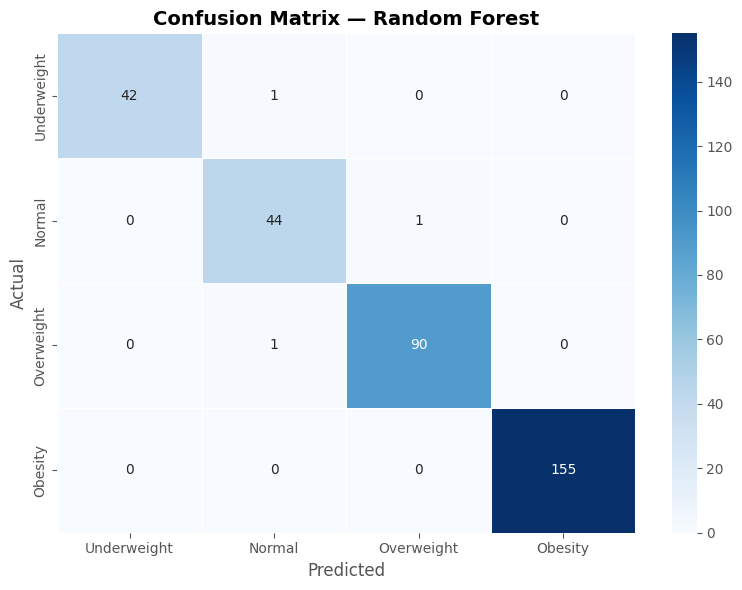

In [92]:
label_names = ['Underweight', 'Normal', 'Overweight', 'Obesity']
cm = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


### Feature Importance (Model Terbaik)

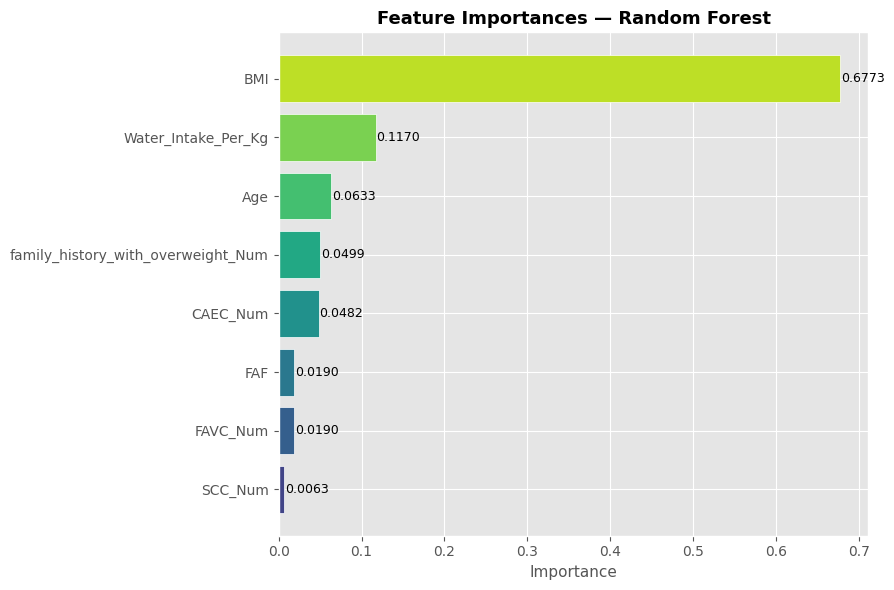

In [93]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X_train.columns.tolist()

# Cek apakah model punya feature_importances_ atau coef_
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    title_suffix = 'Feature Importances'
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_).mean(axis=0)
    title_suffix = 'Mean |Coefficient|'
else:
    importances = None
    print("Model ini tidak memiliki atribut feature_importances_ atau coef_.")
    print("Gunakan permutation importance atau SHAP untuk interpretasi lebih lanjut.")

if importances is not None:
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True)

    plt.figure(figsize=(9, 6))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(fi_df)))
    bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='white')
    for bar, val in zip(bars, fi_df['Importance']):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
    plt.title(f'{title_suffix} — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance', fontsize=11)
    plt.tight_layout()
    plt.show()


### Final Training & Prediksi Data Test

In [94]:
# Re-train model terbaik menggunakan SELURUH data training
best_model_final = models[best_model_name]
best_model_final.fit(X_train, y_train)

# Prediksi pada df_test_scaled (data test tanpa label)
y_pred_test = best_model_final.predict(df_test_scaled)

# Mapping numerik ke label asli
label_map = {0: 'Underweight', 1: 'Normal', 2: 'Overweight', 3: 'Obesity'}
y_pred_label = pd.Series(y_pred_test).map(label_map)

# Tambahkan hasil prediksi ke df_test_scaled
df_test_result = df_test_scaled.copy()
df_test_result['Weight_Status_Pred_Num']   = y_pred_test
df_test_result['Weight_Status_Pred_Label'] = y_pred_label.values

print(f"✅ Prediksi selesai untuk {len(df_test_result)} data test")
print()
print("Distribusi Hasil Prediksi:")
print(y_pred_label.value_counts())
print()
print("Sample Hasil Prediksi (5 teratas):")
print(df_test_result[['Weight_Status_Pred_Label']].head())


✅ Prediksi selesai untuk 418 data test

Distribusi Hasil Prediksi:
Obesity        195
Overweight     109
Normal          61
Underweight     53
Name: count, dtype: int64

Sample Hasil Prediksi (5 teratas):
  Weight_Status_Pred_Label
0              Underweight
1               Overweight
2                  Obesity
3                  Obesity
4                   Normal


### Distribusi Hasil Prediksi Data Test

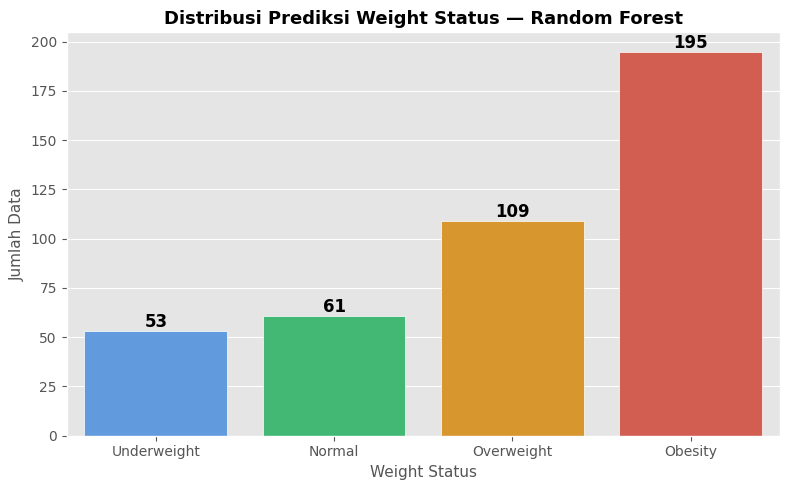

✅ Hasil prediksi disimpan ke 'df_test_predictions.csv'


In [95]:
plt.figure(figsize=(8, 5))
order = ['Underweight', 'Normal', 'Overweight', 'Obesity']
palette = {'Underweight': '#4e9af1', 'Normal': '#2ecc71',
           'Overweight': '#f39c12', 'Obesity': '#e74c3c'}

ax = sns.countplot(x='Weight_Status_Pred_Label', data=df_test_result,
                   order=order, palette=palette, edgecolor='white')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title(f'Distribusi Prediksi Weight Status — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.xlabel('Weight Status', fontsize=11)
plt.ylabel('Jumlah Data', fontsize=11)
plt.tight_layout()
plt.show()

# Simpan hasil prediksi
df_test_result.to_csv('df_test_predictions.csv', index=False)
print("✅ Hasil prediksi disimpan ke 'df_test_predictions.csv'")


### Simpan Model Terbaik

In [96]:
import joblib

model_filename = f'model_obesitas_best.pkl'
joblib.dump(best_model_final, model_filename)

print(f"✅ Model '{best_model_name}' berhasil disimpan sebagai '{model_filename}'")
print()
print("=" * 55)
print("         RINGKASAN AKHIR MODELING")
print("=" * 55)
print(f"  Model Terpilih : {best_model_name}")
print(f"  Accuracy (CV)  : {df_results.loc[best_model_name, 'accuracy']:.4f}")
print(f"  F1-Weighted    : {df_results.loc[best_model_name, 'f1_weighted']:.4f}")
print(f"  F1-Macro       : {df_results.loc[best_model_name, 'f1_macro']:.4f}")
print(f"  File Model     : {model_filename}")
print(f"  File Scaler    : scaler_obesitas.pkl")
print(f"  Prediksi Test  : df_test_predictions.csv")
print("=" * 55)


✅ Model 'Random Forest' berhasil disimpan sebagai 'model_obesitas_best.pkl'

         RINGKASAN AKHIR MODELING
  Model Terpilih : Random Forest
  Accuracy (CV)  : 0.9910
  F1-Weighted    : 0.9910
  F1-Macro       : 0.9861
  File Model     : model_obesitas_best.pkl
  File Scaler    : scaler_obesitas.pkl
  Prediksi Test  : df_test_predictions.csv


---
## Deep Learning Model (TensorFlow Functional API)

Model deep learning dibangun menggunakan **TensorFlow Functional API** dengan komponen kustom lanjutan:
- **Custom Layer** : `ResidualBlock` — blok residual dengan skip connection & batch normalization
- **Custom Loss** : `FocalLoss` — menangani ketidakseimbangan kelas dengan down-weighting easy examples
- **Custom Callback** : `TrainingMonitor` — monitoring F1-score per epoch + learning rate scheduler otomatis


### Import Library TensorFlow

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelBinarizer
import joblib

# Seed reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU Available      : {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow version : 2.20.0
GPU Available      : False


### Memuat & Mempersiapkan Data

In [98]:
# Load data hasil scaling
df_train_scaled = pd.read_csv('df_train_scaled.csv')
df_test_scaled  = pd.read_csv('df_test_scaled.csv')

# Fitur dan target
feature_cols = [c for c in df_train_scaled.columns if c != 'Weight_Status_Num']
X = df_train_scaled[feature_cols].values.astype(np.float32)
y = df_train_scaled['Weight_Status_Num'].values.astype(int)

NUM_FEATURES = X.shape[1]
NUM_CLASSES  = len(np.unique(y))
CLASS_NAMES  = ['Underweight', 'Normal', 'Overweight', 'Obesity']

# Train / Val split (80:20 dari training set)
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# One-Hot Encoding untuk target (dibutuhkan oleh Focal Loss)
y_tr_cat  = to_categorical(y_tr,  num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)

# Hitung bobot kelas untuk menyeimbangkan pelatihan
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight_dict = dict(enumerate(class_weights_arr))

print(f"Jumlah Fitur  : {NUM_FEATURES}")
print(f"Jumlah Kelas  : {NUM_CLASSES}  → {CLASS_NAMES}")
print(f"Shape X_train : {X_tr.shape}")
print(f"Shape X_val   : {X_val.shape}")
print(f"\nClass Weights : {class_weight_dict}")


Jumlah Fitur  : 8
Jumlah Kelas  : 4  → ['Underweight', 'Normal', 'Overweight', 'Obesity']
Shape X_train : (1335, 8)
Shape X_val   : (334, 8)

Class Weights : {0: np.float64(1.9517543859649122), 1: np.float64(1.8541666666666667), 2: np.float64(0.9219613259668509), 3: np.float64(0.5365755627009646)}


### ① Custom Layer — `ResidualBlock`

In [99]:
class ResidualBlock(layers.Layer):
    """
    Custom Layer: Blok residual dengan skip connection.

    Arsitektur per blok:
        Input ──► Dense ──► BatchNorm ──► ReLU ──► Dropout
                                                       │
        Input ──► (Dense 1×1 jika ukuran beda) ────────┤
                                                       ▼
                                                    Output (Add)

    Skip connection membantu gradient flow pada jaringan yang dalam
    dan mencegah vanishing gradient.
    """

    def __init__(self, units, dropout_rate=0.3, l2_reg=1e-4, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.units        = units
        self.dropout_rate = dropout_rate
        self.l2_reg       = l2_reg

    def build(self, input_shape):
        reg = regularizers.l2(self.l2_reg)

        # Layer utama
        self.dense1 = layers.Dense(self.units, kernel_regularizer=reg)
        self.bn1    = layers.BatchNormalization()
        self.act1   = layers.Activation('relu')
        self.drop1  = layers.Dropout(self.dropout_rate)

        self.dense2 = layers.Dense(self.units, kernel_regularizer=reg)
        self.bn2    = layers.BatchNormalization()
        self.act2   = layers.Activation('relu')
        self.drop2  = layers.Dropout(self.dropout_rate)

        # Proyeksi skip connection (jika dimensi input ≠ units)
        if input_shape[-1] != self.units:
            self.proj = layers.Dense(self.units, use_bias=False)
        else:
            self.proj = None

        self.add = layers.Add()
        super(ResidualBlock, self).build(input_shape)

    def call(self, inputs, training=False):
        # Path utama
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = self.act1(x)
        x = self.drop1(x, training=training)

        x = self.dense2(x)
        x = self.bn2(x, training=training)
        x = self.act2(x)
        x = self.drop2(x, training=training)

        # Skip connection
        shortcut = self.proj(inputs) if self.proj is not None else inputs
        return self.add([x, shortcut])

    def get_config(self):
        config = super().get_config()
        config.update({
            'units'       : self.units,
            'dropout_rate': self.dropout_rate,
            'l2_reg'      : self.l2_reg,
        })
        return config

print("✅ Custom Layer 'ResidualBlock' berhasil didefinisikan!")
print(f"   → Residual connection + BatchNorm + Dropout(rate=0.3)")


✅ Custom Layer 'ResidualBlock' berhasil didefinisikan!
   → Residual connection + BatchNorm + Dropout(rate=0.3)


### ② Custom Loss Function — `FocalLoss`

In [100]:
class FocalLoss(keras.losses.Loss):
    """
    Custom Loss: Focal Loss untuk menangani ketidakseimbangan kelas.

    Formula:
        FL(p_t) = -α_t × (1 - p_t)^γ × log(p_t)

    Parameter:
        gamma (γ) : Focusing parameter. Memperbesar penalti untuk
                    hard/misclassified examples. γ=0 → Cross-Entropy biasa.
        alpha (α) : Weighting factor untuk keseimbangan kelas positif/negatif.

    Keunggulan vs Cross-Entropy biasa:
        - Easy examples (p_t tinggi) diberi bobot lebih kecil
        - Hard examples (p_t rendah) tetap mendapat perhatian lebih besar
        - Sangat efektif pada dataset yang tidak seimbang
    """

    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss', **kwargs):
        super(FocalLoss, self).__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # Clip prediksi agar tidak log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross-entropy: -y_true * log(y_pred)
        ce = -y_true * tf.math.log(y_pred)

        # Focal weight: (1 - p_t)^gamma
        p_t          = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        # Focal loss = alpha * focal_weight * cross_entropy
        focal_loss = self.alpha * focal_weight * ce

        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config

print("✅ Custom Loss 'FocalLoss' berhasil didefinisikan!")
print(f"   → gamma=2.0 (focusing), alpha=0.25 (weighting)")


✅ Custom Loss 'FocalLoss' berhasil didefinisikan!
   → gamma=2.0 (focusing), alpha=0.25 (weighting)


### ③ Custom Callback — `TrainingMonitor`

In [101]:
class TrainingMonitor(keras.callbacks.Callback):
    """
    Custom Callback: Monitor pelatihan dengan fitur lanjutan.

    Fitur:
        1. Logging F1-Score (Macro & Weighted) per epoch pada validation set
        2. Early Stopping berbasis val_f1_weighted (bukan val_loss)
        3. Learning Rate Scheduler otomatis (ReduceLROnPlateau-style kustom)
        4. Menyimpan model terbaik berdasarkan val_f1_weighted
        5. Rekap ringkas di akhir pelatihan
    """

    def __init__(self, val_data, patience=10, lr_patience=5,
                 lr_factor=0.5, min_lr=1e-6, save_path='best_model_dl.keras'):
        super(TrainingMonitor, self).__init__()
        self.X_val       = val_data[0]
        self.y_val_true  = val_data[1]          # Integer labels
        self.patience    = patience
        self.lr_patience = lr_patience
        self.lr_factor   = lr_factor
        self.min_lr      = min_lr
        self.save_path   = save_path

        # State
        self.best_f1      = -np.inf
        self.wait          = 0
        self.lr_wait       = 0
        self.history_f1    = []
        self.history_loss  = []
        self.best_epoch    = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Prediksi & hitung F1
        y_pred_prob = self.model.predict(self.X_val, verbose=0)
        y_pred      = np.argmax(y_pred_prob, axis=1)

        f1_macro    = f1_score(self.y_val_true, y_pred, average='macro',    zero_division=0)
        f1_weighted = f1_score(self.y_val_true, y_pred, average='weighted', zero_division=0)
        val_loss    = logs.get('val_loss', 0)

        # Simpan ke history
        self.history_f1.append(f1_weighted)
        self.history_loss.append(val_loss)

        # Current LR
        current_lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))

        # Print log tiap epoch
        print(f"  Epoch {epoch+1:03d} | val_loss={val_loss:.4f} | "
              f"F1-macro={f1_macro:.4f} | F1-weighted={f1_weighted:.4f} | LR={current_lr:.2e}")

        # ── Best model checkpoint ──────────────────────────────────
        if f1_weighted > self.best_f1:
            self.best_f1    = f1_weighted
            self.best_epoch = epoch + 1
            self.wait       = 0
            self.lr_wait    = 0
            self.model.save(self.save_path)
            print(f"  ✅ Model terbaik disimpan! (F1-weighted={f1_weighted:.4f})")
        else:
            self.wait    += 1
            self.lr_wait += 1

            # ── LR Reduction ───────────────────────────────────────
            if self.lr_wait >= self.lr_patience:
                new_lr = max(current_lr * self.lr_factor, self.min_lr)
                # Menggunakan .assign() untuk mengubah nilai tf.Variable secara langsung
                self.model.optimizer.learning_rate.assign(new_lr)
                print(f"  ⬇️  LR diturunkan: {current_lr:.2e} → {new_lr:.2e}")
                self.lr_wait = 0

            # ── Early Stopping ─────────────────────────────────────
            if self.wait >= self.patience:
                self.model.stop_training = True
                print(f"\n  🛑 Early Stopping! Tidak ada improvement selama {self.patience} epoch.")
                print(f"     Best epoch: {self.best_epoch} | Best F1-weighted: {self.best_f1:.4f}")

    def on_train_end(self, logs=None):
        print(f"\n{'='*55}")
        print(f"  RINGKASAN PELATIHAN")
        print(f"{'='*55}")
        print(f"  Best Epoch       : {self.best_epoch}")
        print(f"  Best F1-Weighted : {self.best_f1:.4f}")
        print(f"  Model Tersimpan  : {self.save_path}")
        print(f"{'='*55}")

print("✅ Custom Callback 'TrainingMonitor' berhasil didefinisikan!")
print("   → F1 Monitoring + Early Stopping + LR Scheduler + Model Checkpoint")

✅ Custom Callback 'TrainingMonitor' berhasil didefinisikan!
   → F1 Monitoring + Early Stopping + LR Scheduler + Model Checkpoint


### Membangun Model — TensorFlow Functional API

In [102]:
def build_obesity_model(num_features, num_classes):
    """
    Arsitektur model klasifikasi obesitas menggunakan Functional API.

    Topology:
        Input (8)
          │
          ├─► Dense(64) + BatchNorm + ReLU          [Feature Projection]
          │
          ├─► ResidualBlock(128)                     [Custom Layer ①]
          │
          ├─► ResidualBlock(64)                      [Custom Layer ②]
          │
          ├─► ResidualBlock(32)                      [Custom Layer ③]
          │
          ├─► GlobalAveragePooling (Flatten)
          │
          └─► Dense(num_classes, softmax)            [Output]
    """
    inputs = Input(shape=(num_features,), name='input_features')

    # ── Feature Projection Layer ────────────────────────────────────
    x = layers.Dense(64, name='projection')(inputs)
    x = layers.BatchNormalization(name='bn_projection')(x)
    x = layers.Activation('relu', name='act_projection')(x)
    x = layers.Dropout(0.2, name='drop_projection')(x)

    # ── Custom ResidualBlock Layers ─────────────────────────────────
    x = ResidualBlock(128, dropout_rate=0.3, name='res_block_1')(x)
    x = ResidualBlock(64,  dropout_rate=0.3, name='res_block_2')(x)
    x = ResidualBlock(32,  dropout_rate=0.2, name='res_block_3')(x)

    # ── Output Layer ────────────────────────────────────────────────
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='ObesityClassifier_DL')
    return model

# Build dan tampilkan ringkasan
model_dl = build_obesity_model(NUM_FEATURES, NUM_CLASSES)
model_dl.summary()


Model: "ObesityClassifier_DL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection (Dense)              │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_projection                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_projection (Activation)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_projection (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)     │ (None, 128)            │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)     │ (None, 64)             │        21,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_3 (ResidualBlock)     │ (None, 32)             │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,572 (240.52 KB)

 Trainable params: 60,548 (236.52 KB)

 Non-trainable params: 1,024 (4.00 KB)

### Visualisasi Arsitektur Model

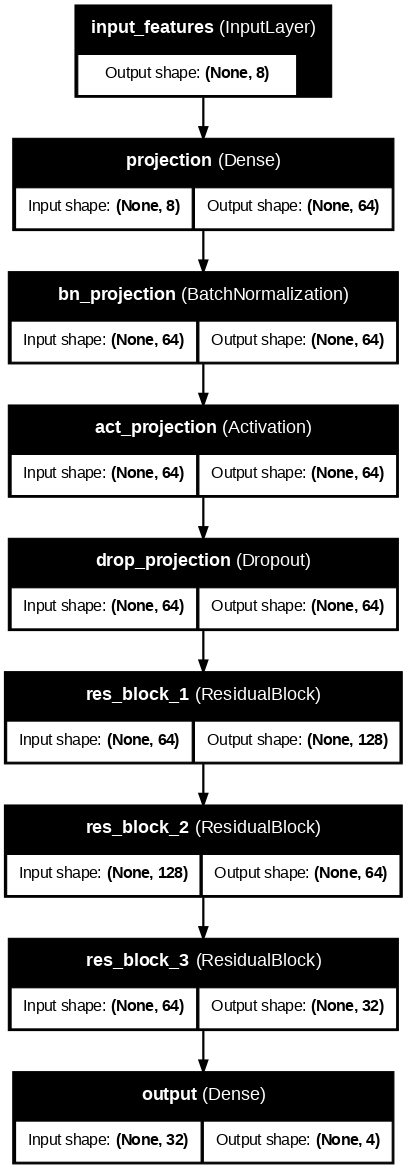

✅ Diagram arsitektur model berhasil ditampilkan.


In [103]:
try:
    keras.utils.plot_model(
        model_dl,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=80
    )
    from IPython.display import Image
    display(Image('model_architecture.png'))
    print("✅ Diagram arsitektur model berhasil ditampilkan.")
except Exception as e:
    print(f"ℹ️  Tidak dapat menampilkan diagram grafis: {e}")
    print("   Gunakan model_dl.summary() di atas untuk melihat arsitektur.")


### Compile Model

In [104]:
# Gunakan Custom Loss: FocalLoss
focal_loss = FocalLoss(gamma=2.0, alpha=0.25)

model_dl.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = focal_loss,                            # ← Custom Loss
    metrics   = ['accuracy',
                 keras.metrics.AUC(name='auc', multi_label=False)]
)

print("✅ Model berhasil dikompilasi!")
print(f"   Optimizer : Adam (lr=1e-3)")
print(f"   Loss      : FocalLoss (gamma=2.0, alpha=0.25)  ← Custom Loss")
print(f"   Metrics   : accuracy, AUC")


✅ Model berhasil dikompilasi!
   Optimizer : Adam (lr=1e-3)
   Loss      : FocalLoss (gamma=2.0, alpha=0.25)  ← Custom Loss
   Metrics   : accuracy, AUC


### Training Model

In [105]:
# Custom Callback: TrainingMonitor
monitor_callback = TrainingMonitor(
    val_data   = (X_val, y_val),       # ← Integer labels untuk F1 calculation
    patience   = 15,
    lr_patience= 7,
    lr_factor  = 0.5,
    min_lr     = 1e-7,
    save_path  = 'best_model_dl.keras'
)

print("="*60)
print("  MEMULAI PROSES TRAINING")
print("="*60)

history = model_dl.fit(
    X_tr, y_tr_cat,
    validation_data = (X_val, y_val_cat),
    epochs          = 100,
    batch_size      = 64,
    class_weight    = class_weight_dict,
    callbacks       = [monitor_callback],   # ← Custom Callback
    verbose         = 0                     # Logging ditangani Custom Callback
)


  MEMULAI PROSES TRAINING
  Epoch 001 | val_loss=0.1376 | F1-macro=0.4514 | F1-weighted=0.5076 | LR=1.00e-03
  ✅ Model terbaik disimpan! (F1-weighted=0.5076)
  Epoch 002 | val_loss=0.1122 | F1-macro=0.7154 | F1-weighted=0.7328 | LR=1.00e-03
  ✅ Model terbaik disimpan! (F1-weighted=0.7328)
  Epoch 003 | val_loss=0.1055 | F1-macro=0.7023 | F1-weighted=0.7180 | LR=1.00e-03
  Epoch 004 | val_loss=0.1001 | F1-macro=0.7328 | F1-weighted=0.7444 | LR=1.00e-03
  ✅ Model terbaik disimpan! (F1-weighted=0.7444)
  Epoch 005 | val_loss=0.0856 | F1-macro=0.7898 | F1-weighted=0.8275 | LR=1.00e-03
  ✅ Model terbaik disimpan! (F1-weighted=0.8275)
  Epoch 006 | val_loss=0.0840 | F1-macro=0.7847 | F1-weighted=0.8210 | LR=1.00e-03
  Epoch 007 | val_loss=0.0757 | F1-macro=0.8197 | F1-weighted=0.8566 | LR=1.00e-03
  ✅ Model terbaik disimpan! (F1-weighted=0.8566)
  Epoch 008 | val_loss=0.0719 | F1-macro=0.8343 | F1-weighted=0.8778 | LR=1.00e-03
  ✅ Model terbaik disimpan! (F1-weighted=0.8778)
  Epoch 009 | va

### Kurva Pelatihan

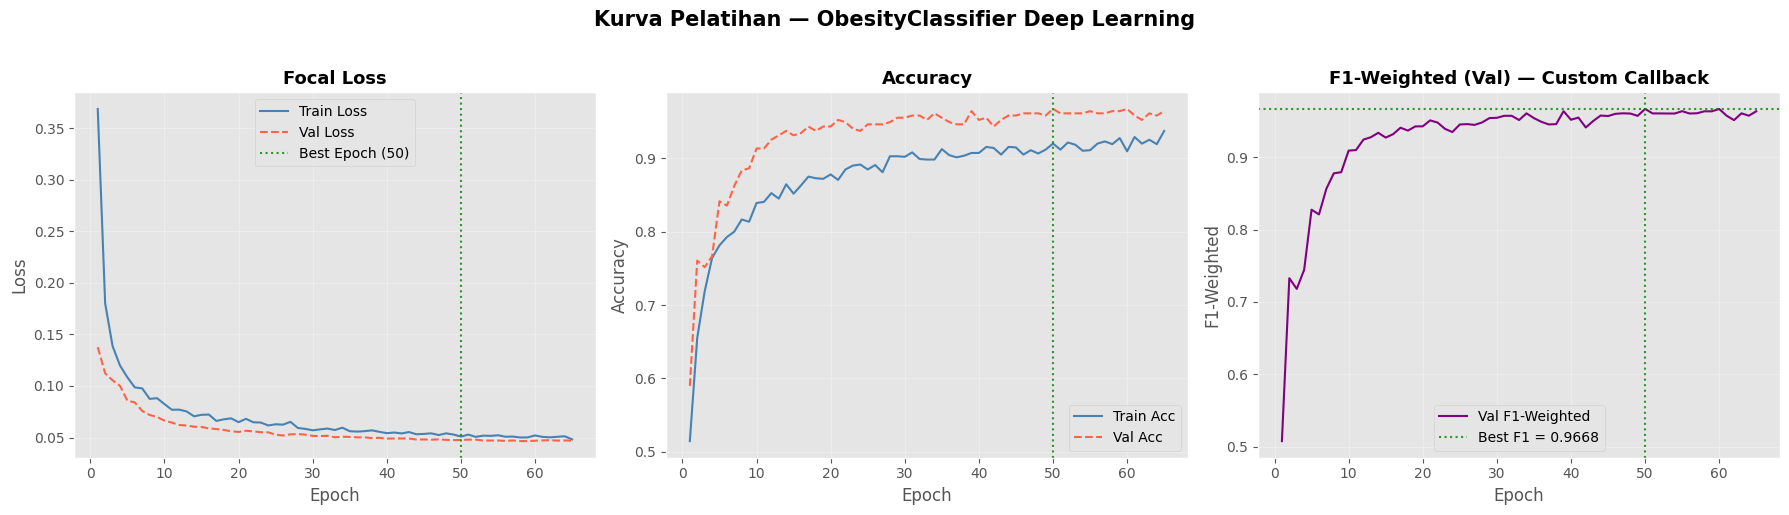

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_ran = range(1, len(history.history["loss"]) + 1)

# Loss
axes[0].plot(epochs_ran, history.history["loss"],     label="Train Loss", color="steelblue")
axes[0].plot(epochs_ran, history.history["val_loss"], label="Val Loss",   color="tomato", linestyle="--")
axes[0].axvline(monitor_callback.best_epoch, color="green", linestyle=":", alpha=0.8, label=f"Best Epoch ({monitor_callback.best_epoch})")
axes[0].set_title("Focal Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history.history["accuracy"],     label="Train Acc", color="steelblue")
axes[1].plot(epochs_ran, history.history["val_accuracy"], label="Val Acc",   color="tomato", linestyle="--")
axes[1].axvline(monitor_callback.best_epoch, color="green", linestyle=":", alpha=0.8)
axes[1].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

# F1-Weighted (dari Custom Callback)
axes[2].plot(range(1, len(monitor_callback.history_f1) + 1),
             monitor_callback.history_f1, color="purple", label="Val F1-Weighted")
axes[2].axhline(monitor_callback.best_f1, color="green", linestyle=":", alpha=0.8,
                label=f"Best F1 = {monitor_callback.best_f1:.4f}")
axes[2].axvline(monitor_callback.best_epoch, color="green", linestyle=":", alpha=0.8)
axes[2].set_title("F1-Weighted (Val) — Custom Callback", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1-Weighted")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Kurva Pelatihan — ObesityClassifier Deep Learning", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Evaluasi Model Terbaik (Validation Set)

In [107]:
# Load model terbaik yang disimpan Custom Callback
best_model_dl = keras.models.load_model(
    "best_model_dl.keras",
    custom_objects={
        "ResidualBlock": ResidualBlock,
        "FocalLoss"    : FocalLoss,
        "TrainingMonitor": TrainingMonitor
    }
)

# Prediksi
y_prob_val = best_model_dl.predict(X_val, verbose=0)
y_pred_val = np.argmax(y_prob_val, axis=1)

print("="*55)
print("  EVALUASI MODEL DEEP LEARNING (Validation Set)")
print("="*55)
print(f"Accuracy  : {(y_pred_val == y_val).mean():.4f}")
print(f"F1-Macro  : {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print(f"F1-Weight : {f1_score(y_val, y_pred_val, average='weighted'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_val, y_pred_val, target_names=CLASS_NAMES))


  EVALUASI MODEL DEEP LEARNING (Validation Set)
Accuracy  : 0.9671
F1-Macro  : 0.9566
F1-Weight : 0.9668

Classification Report:
              precision    recall  f1-score   support

 Underweight       1.00      0.95      0.98        43
      Normal       0.93      0.89      0.91        45
  Overweight       0.95      0.96      0.95        91
     Obesity       0.98      1.00      0.99       155

    accuracy                           0.97       334
   macro avg       0.96      0.95      0.96       334
weighted avg       0.97      0.97      0.97       334



### Confusion Matrix — Deep Learning Model

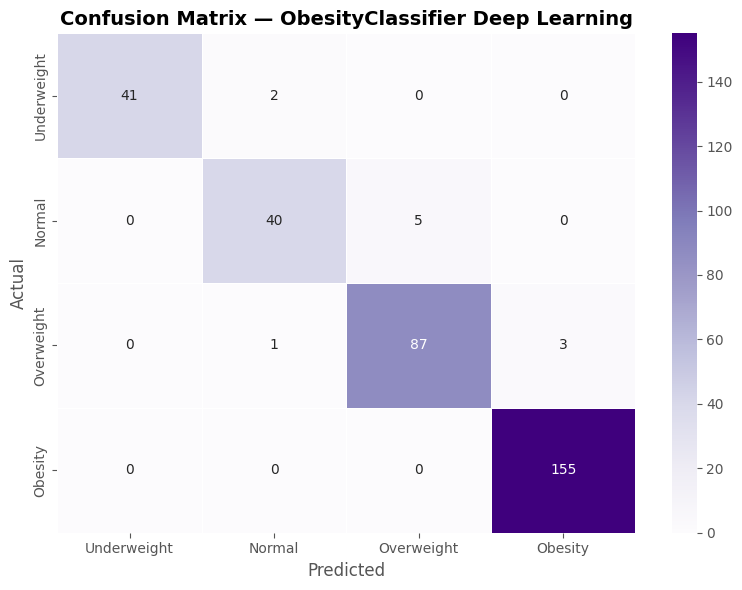

In [108]:
cm_dl = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Purples",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor="white")
plt.title("Confusion Matrix — ObesityClassifier Deep Learning", fontsize=14, fontweight="bold")
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.tight_layout()
plt.show()


### Menyimpan Model dalam Format Produksi

In [109]:
# ── 1. Format .keras (Recommended) ─────────────────────────────────
best_model_dl.save("model_obesitas_dl.keras")
print("✅ Model disimpan dalam format .keras : model_obesitas_dl.keras")

# ── 2. Format SavedModel (TF Serving compatible) ────────────────────
best_model_dl.export("model_obesitas_savedmodel")
print("✅ Model disimpan dalam format SavedModel : model_obesitas_savedmodel/")

# ── Verifikasi file tersimpan ───────────────────────────────────────
import os
keras_size = os.path.getsize("model_obesitas_dl.keras") / 1024
print(f"\nUkuran file .keras : {keras_size:.1f} KB")
print("\nStruktur SavedModel:")
for root, dirs, files in os.walk("model_obesitas_savedmodel"):
    level = root.replace("model_obesitas_savedmodel", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  {f}")


✅ Model disimpan dalam format .keras : model_obesitas_dl.keras
Saved artifact at 'model_obesitas_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='input_features')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137604447024336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604447022608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604447022992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604447024528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604447023568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604447024144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604608842000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604608842192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604608842384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604608838160: Ten

### Kode Inference — Prediksi Data Baru

In [110]:
# ─────────────────────────────────────────────────────────────────────
# INFERENCE PIPELINE
# ─────────────────────────────────────────────────────────────────────

def predict_obesity(input_data, model_path="model_obesitas_dl.keras",
                    scaler_path="scaler_obesitas.pkl"):
    """
    Fungsi inference untuk memprediksi Weight Status dari data baru.

    Parameter:
        input_data (dict atau DataFrame): Data input dengan fitur:
            - Age                          : Usia (tahun)
            - BMI                          : Body Mass Index
            - Water_Intake_Per_Kg          : Konsumsi air per kg berat badan
            - FAF                          : Frekuensi aktivitas fisik
            - family_history_with_overweight_Num : Riwayat keluarga (0/1)
            - CAEC_Num                     : Konsumsi makanan di antara makan (0-3)
            - FAVC_Num                     : Konsumsi makanan tinggi kalori (0/1)
            - SCC_Num                      : Monitor kalori (0/1)

    Return:
        dict: label prediksi, probabilitas tiap kelas, indeks kelas
    """
    CLASS_NAMES_INF = ['Underweight', 'Normal', 'Overweight', 'Obesity']
    COLS_TO_SCALE   = ['Age', 'BMI', 'Water_Intake_Per_Kg']
    FEATURE_ORDER   = ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF',
                       'family_history_with_overweight_Num',
                       'CAEC_Num', 'FAVC_Num', 'SCC_Num']

    # 1. Konversi ke DataFrame
    if isinstance(input_data, dict):
        df_input = pd.DataFrame([input_data])
    else:
        df_input = input_data.copy()

    # 2. Pastikan urutan kolom benar
    df_input = df_input[FEATURE_ORDER]

    # 3. Load & terapkan scaler
    scaler = joblib.load(scaler_path)
    df_scaled = df_input.copy()
    df_scaled[COLS_TO_SCALE] = scaler.transform(df_input[COLS_TO_SCALE])

    # 4. Load model & prediksi
    model = keras.models.load_model(
        model_path,
        custom_objects={"ResidualBlock": ResidualBlock, "FocalLoss": FocalLoss}
    )
    X_inf = df_scaled.values.astype(np.float32)
    proba = model.predict(X_inf, verbose=0)

    # 5. Decode hasil
    pred_idx   = np.argmax(proba, axis=1)
    pred_label = [CLASS_NAMES_INF[i] for i in pred_idx]

    results = []
    for i in range(len(pred_idx)):
        results.append({
            "predicted_class" : pred_label[i],
            "class_index"     : int(pred_idx[i]),
            "probabilities"   : {cls: float(f"{p:.4f}")
                                 for cls, p in zip(CLASS_NAMES_INF, proba[i])}
        })

    return results[0] if len(results) == 1 else results


# ─────────────────────────────────────────────────────────────────────
# CONTOH PENGGUNAAN INFERENCE
# ─────────────────────────────────────────────────────────────────────

# Contoh 1: Satu sampel (individu dengan risiko Obesity)
sample_1 = {
    "Age"                                  : 35,
    "BMI"                                  : 32.5,
    "Water_Intake_Per_Kg"                  : 0.025,
    "FAF"                                  : 0,
    "family_history_with_overweight_Num"   : 1,
    "CAEC_Num"                             : 2,
    "FAVC_Num"                             : 1,
    "SCC_Num"                              : 0,
}

result_1 = predict_obesity(sample_1)
print("━"*50)
print("  HASIL INFERENCE — Sampel 1 (Risiko Tinggi)")
print("━"*50)
print(f"  Prediksi    : {result_1['predicted_class']}")
print(f"  Class Index : {result_1['class_index']}")
print("  Probabilitas:")
for cls, prob in result_1["probabilities"].items():
    bar = "█" * int(prob * 30)
    print(f"    {cls:<15}: {prob:.4f}  {bar}")

print()

# Contoh 2: Individu dengan profil Normal/Healthy
sample_2 = {
    "Age"                                  : 24,
    "BMI"                                  : 21.8,
    "Water_Intake_Per_Kg"                  : 0.040,
    "FAF"                                  : 3,
    "family_history_with_overweight_Num"   : 0,
    "CAEC_Num"                             : 1,
    "FAVC_Num"                             : 0,
    "SCC_Num"                              : 1,
}

result_2 = predict_obesity(sample_2)
print("━"*50)
print("  HASIL INFERENCE — Sampel 2 (Profil Sehat)")
print("━"*50)
print(f"  Prediksi    : {result_2['predicted_class']}")
print(f"  Class Index : {result_2['class_index']}")
print("  Probabilitas:")
for cls, prob in result_2["probabilities"].items():
    bar = "█" * int(prob * 30)
    print(f"    {cls:<15}: {prob:.4f}  {bar}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HASIL INFERENCE — Sampel 1 (Risiko Tinggi)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Prediksi    : Obesity
  Class Index : 3
  Probabilitas:
    Underweight    : 0.0000  
    Normal         : 0.0007  
    Overweight     : 0.2163  ██████
    Obesity        : 0.7830  ███████████████████████

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HASIL INFERENCE — Sampel 2 (Profil Sehat)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Prediksi    : Normal
  Class Index : 1
  Probabilitas:
    Underweight    : 0.1871  █████
    Normal         : 0.7334  ██████████████████████
    Overweight     : 0.0793  ██
    Obesity        : 0.0001  


### Prediksi Batch pada Data Test

In [111]:
# Prediksi seluruh df_test_scaled menggunakan model DL
X_test_inf   = df_test_scaled.values.astype(np.float32)
y_prob_test  = best_model_dl.predict(X_test_inf, verbose=0)
y_pred_test  = np.argmax(y_prob_test, axis=1)
label_map    = {0: "Underweight", 1: "Normal", 2: "Overweight", 3: "Obesity"}

df_test_dl_result = df_test_scaled.copy()
df_test_dl_result["Weight_Status_Pred_Num"]   = y_pred_test
df_test_dl_result["Weight_Status_Pred_Label"] = pd.Series(y_pred_test).map(label_map).values

# Tambahkan kolom probabilitas tiap kelas
for i, cls in enumerate(CLASS_NAMES):
    df_test_dl_result[f"prob_{cls}"] = y_prob_test[:, i].round(4)

print(f"✅ Prediksi batch selesai untuk {len(df_test_dl_result)} data")
print()
print("Distribusi Prediksi:")
print(df_test_dl_result["Weight_Status_Pred_Label"].value_counts())
print()
print("Sample Hasil (5 teratas):")
print(df_test_dl_result[["Weight_Status_Pred_Label"] +
                          [f"prob_{c}" for c in CLASS_NAMES]].head())

# Simpan hasil prediksi DL
df_test_dl_result.to_csv("df_test_predictions_dl.csv", index=False)
print("\n✅ Hasil prediksi DL disimpan ke 'df_test_predictions_dl.csv'")


✅ Prediksi batch selesai untuk 418 data

Distribusi Prediksi:
Weight_Status_Pred_Label
Obesity        194
Overweight     114
Normal          58
Underweight     52
Name: count, dtype: int64

Sample Hasil (5 teratas):
  Weight_Status_Pred_Label  prob_Underweight  prob_Normal  prob_Overweight  \
0              Underweight             0.733        0.265            0.002   
1               Overweight             0.005        0.149            0.807   
2                  Obesity             0.000        0.000            0.001   
3                  Obesity             0.000        0.000            0.000   
4                   Normal             0.043        0.939            0.017   

   prob_Obesity  
0         0.000  
1         0.039  
2         0.999  
3         1.000  
4         0.000  

✅ Hasil prediksi DL disimpan ke 'df_test_predictions_dl.csv'


### Ringkasan Akhir Deep Learning

In [112]:
print("=" * 60)
print("         RINGKASAN DEEP LEARNING MODEL")
print("=" * 60)
print()
print("  ARSITEKTUR:")
print("  ├─ Framework    : TensorFlow / Keras Functional API")
print("  ├─ Input        : 8 fitur numerik")
print("  ├─ Hidden       : Projection + 3× ResidualBlock")
print("  └─ Output       : 4 kelas (softmax)")
print()
print("  KOMPONEN KUSTOM LANJUTAN:")
print("  ├─ ① Custom Layer    : ResidualBlock")
print("  │    Skip connection + BatchNorm + Dropout")
print("  ├─ ② Custom Loss     : FocalLoss (γ=2, α=0.25)")
print("  │    Down-weight easy examples, fokus hard examples")
print("  └─ ③ Custom Callback : TrainingMonitor")
print("       F1 Monitoring + Early Stopping + LR Scheduler")
print()
print("  PERFORMA TERBAIK (Validation Set):")
print(f"  ├─ F1-Weighted : {monitor_callback.best_f1:.4f}")
print(f"  └─ Best Epoch  : {monitor_callback.best_epoch}")
print()
print("  FILE OUTPUT:")
print("  ├─ model_obesitas_dl.keras          ← Format .keras")
print("  ├─ model_obesitas_savedmodel/       ← Format SavedModel")
print("  ├─ best_model_dl.keras              ← Best checkpoint")
print("  └─ df_test_predictions_dl.csv       ← Hasil prediksi")
print("=" * 60)


         RINGKASAN DEEP LEARNING MODEL

  ARSITEKTUR:
  ├─ Framework    : TensorFlow / Keras Functional API
  ├─ Input        : 8 fitur numerik
  ├─ Hidden       : Projection + 3× ResidualBlock
  └─ Output       : 4 kelas (softmax)

  KOMPONEN KUSTOM LANJUTAN:
  ├─ ① Custom Layer    : ResidualBlock
  │    Skip connection + BatchNorm + Dropout
  ├─ ② Custom Loss     : FocalLoss (γ=2, α=0.25)
  │    Down-weight easy examples, fokus hard examples
  └─ ③ Custom Callback : TrainingMonitor
       F1 Monitoring + Early Stopping + LR Scheduler

  PERFORMA TERBAIK (Validation Set):
  ├─ F1-Weighted : 0.9668
  └─ Best Epoch  : 50

  FILE OUTPUT:
  ├─ model_obesitas_dl.keras          ← Format .keras
  ├─ model_obesitas_savedmodel/       ← Format SavedModel
  ├─ best_model_dl.keras              ← Best checkpoint
  └─ df_test_predictions_dl.csv       ← Hasil prediksi
